# 1) Resumen y Objetivos


**Resumen:**
Este proyecto desarrolla y compara un sistema de pronóstico a escala municipal, de la ciudad de Santiago de Cali, Colombia, evaluando distintos enfoques estadísticos, machine learning y deep learning. Se integran datos epidemiológicos y climáticos para predecir semanalmente los casos del dengue y clasificar el riesgo de brote basados en el canal endémico. La evaluación se realiza en horizontes de 1, 2, 3 y 4 semanas mediante una ventana rodante. Los resultados buscan fortalecer la toma de decisiones en salud pública y apoyar la activación oportuna de medidas de control vectorial.

**Objetivos:**

1. Construir los modelos de referencia (benchmarks).
    - Aplicar métodos estadísticos: medias móviles, suavización exponencial (Holt-Winters), ARIMA/SARIMA, SARIMAX y Prophet.
    - Entrenar modelos de machine learning: XGBoost, Random Forest y LightGBM.
    - DL: LSTM, TCN,MLP.

2. Evaluar el desempeño en horizontes de 1, 2, 3 y 4 semanas utilizando ventana rodante.

3. Formular las alertas convirtiendo los pronósticos en clasificaciones de brote mediante umbrales y calibración.


# 2) Carga y preparación de datos:

In [4]:
# Importación de módulos y paquetes necesarios para el análisis

# Manejo y manipulación de datos numéricos y tabulares
import numpy as np
import pandas as pd

# manejo de rutas y archivos
import os

# Utilidades de tiempo para medir duración de procesos
import time
from datetime import timedelta

# Visualización de gráficas y personalización de estilos
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Datos geoespaciales para mapas y geometrías
import geopandas as gpd

# Descomposición de series temporales en tendencia, estacionalidad y residuo
from statsmodels.tsa.seasonal import seasonal_decompose

# Prueba de estacionariedad Dickey-Fuller aumentada
from statsmodels.tsa.stattools import adfuller

# Prueba de autocorrelación de Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

# Gráficos de autocorrelación (ACF) y autocorrelación parcial (PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Modelos clásicos de series de tiempo: ARIMA, Holt-Winters y SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Selección automática de órdenes ARIMA mediante criterios de información
import pmdarima as pm

# Modelo Prophet para forecasting con estacionalidad múltiple
from prophet import Prophet

# Optimización de hiperparámetros mediante búsqueda bayesiana
import optuna

# Métricas de evaluación para modelos de regresión
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

# Preprocesamiento: escalado de características para modelos sensibles a escala
from sklearn.preprocessing import StandardScaler

# Modelos de Machine Learning: regresión lineal regularizada y métodos de ensemble
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modelos de boosting basados en árboles de decisión con gradiente
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Deep learning: núcleo de PyTorch, capas y utilidades para carga de datos
import torch
import torch.nn as nn
from torch.utils.data import Dataset, TensorDataset, DataLoader

In [2]:
# Métricas helper
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape_pct(y_true, y_pred):
    """MAPE en porcentaje, con protección para ceros."""
    y_true = np.array(y_true, float)
    y_pred = np.array(y_pred, float)
    eps = 1e-6
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)

# Dispositivo para DL
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [3]:
ruta = os.path.join("data", "all_data_with_n_cases_F.parquet")
df = pd.read_parquet(ruta)
print(df.shape)

df.head()

(164115, 141)


,epi_week,y,x,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,band,slope,...,tasa_eb_10000_sd_4w,tasa_eb_10000_max_4w,tasa_eb_10000_min_4w,tasa_eb_10000_sum_4w,tasa_eb_10000_mean_6w,tasa_eb_10000_sd_6w,tasa_eb_10000_max_6w,tasa_eb_10000_min_6w,tasa_eb_10000_sum_6w,n_casos
26460,2015-01,3.322354,-76.591161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26461,2015-01,3.322354,-76.582161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26462,2015-01,3.322354,-76.573161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26463,2015-01,3.322354,-76.564161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26464,2015-01,3.322354,-76.555161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


El dataset contiene tanto variables originales, como características derivadas; generadas a partir de estas (por ejemplo, promedios móviles, diferencias, tasas o indicadores derivados). Para simplificar el análisis y evitar duplicidad de información, filtraremos únicamente las columnas originales. De esta manera, el trabajo posterior se realizará sobre un conjunto de datos base, sin incluir variables que dependen de transformaciones previas.

### 2.1) Selección de variables con información relevante:

In [5]:
cols_origin = ['epi_week','y', 'x', 'ndvi', 'tmax_fore', 'tmin_fore', 'ndwi', 'precip_fore', 'band', 'slope',
               'aspect', 'valle', 'cumbre', 'tpi', 'tasa_eb_10000', 'comercial', 'habitacional', 'industrial',
               'institucional', 'publico', 'suelo_en_transformacion', 'suelo_no_urbanizable', 'estrato',
               'area_humedal_m2', 'distancia_humed_m', 'area_rio_m2', 'distancia_rio_m', 'distancia_pozos_m',
               'n_pozos', 'TP34_1_EDA', 'TP34_2_EDA', 'TP34_3_EDA', 'TP34_4_EDA', 'TP34_5_EDA', 'TP34_6_EDA',
               'TP34_7_EDA', 'TP34_8_EDA', 'TP34_9_EDA', 'hacinamien', 'n_arboles', 'spatial_ref', 'epi_year',
               'epi_week_number', 'pixel_id', 'n_casos']
df_base = df[cols_origin].copy()
print(df_base.shape)
df_base.head()


(164115, 45)


,epi_week,y,x,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,band,slope,...,TP34_7_EDA,TP34_8_EDA,TP34_9_EDA,hacinamien,n_arboles,spatial_ref,epi_year,epi_week_number,pixel_id,n_casos
26460,2015-01,3.322354,-76.591161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2015,1,-76.5911613_3.32235379,NaN
26461,2015-01,3.322354,-76.582161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2015,1,-76.5821613_3.32235379,NaN
26462,2015-01,3.322354,-76.573161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2015,1,-76.5731613_3.32235379,NaN
26463,2015-01,3.322354,-76.564161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2015,1,-76.5641613_3.32235379,NaN
26464,2015-01,3.322354,-76.555161,NaN,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,0,2015,1,-76.5551613_3.32235379,NaN


### 2.2) Exploración Estructural:

In [8]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164115 entries, 26460 to 190574
Data columns (total 45 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   epi_week                 164115 non-null  object 
 1   y                        164115 non-null  float64
 2   x                        164115 non-null  float64
 3   ndvi                     90306 non-null   float64
 4   tmax_fore                90306 non-null   float64
 5   tmin_fore                90306 non-null   float64
 6   ndwi                     90306 non-null   float64
 7   precip_fore              90654 non-null   float64
 8   band                     164115 non-null  int64  
 9   slope                    90654 non-null   float32
 10  aspect                   90654 non-null   float32
 11  valle                    90654 non-null   float64
 12  cumbre                   90654 non-null   float64
 13  tpi                      90654 non-null   float64
 14  tasa_

In [9]:
df_base.duplicated().sum()

np.int64(0)

Verifiquemos el porcentaje de datos nulos en el dataset:

In [10]:
(df_base.isna().mean().sort_values(ascending=False).head(60)*100).round(2)

tasa_eb_10000              49.52
n_casos                    46.67
area_humedal_m2            45.40
distancia_humed_m          45.40
distancia_pozos_m          45.40
industrial                 45.40
suelo_en_transformacion    45.40
institucional              45.40
publico                    45.40
comercial                  45.40
habitacional               45.40
estrato                    45.40
area_rio_m2                45.40
n_pozos                    45.40
distancia_rio_m            45.40
suelo_no_urbanizable       45.40
tmax_fore                  44.97
tmin_fore                  44.97
ndwi                       44.97
ndvi                       44.97
tpi                        44.76
precip_fore                44.76
TP34_1_EDA                 44.76
TP34_3_EDA                 44.76
TP34_2_EDA                 44.76
slope                      44.76
cumbre                     44.76
aspect                     44.76
valle                      44.76
TP34_8_EDA                 44.76
TP34_9_EDA

Obtengamos las fechas únicas y el rango temporal:

In [11]:
# Fechas únicas y rango temporal
print("Semanas únicas:", df_base['epi_week'].nunique())
print("Rango:", df_base['epi_week'].min(), "→", df_base['epi_week'].max())

Semanas únicas: 521
Rango: 2015-01 → 2024-52


Como semanas únicas tenemos 521, quiere decir que existen mas registros tomados en Cali para cada semana única. Procedemos a verificar las variables de ubicación con las que se cuenta:

In [12]:
var_localizacion = ["y", "x", "pixel_id"]
display(df_base[var_localizacion].head(5))
print(df_base[var_localizacion].nunique())

,y,x,pixel_id
26460,3.322354,-76.591161,-76.5911613_3.32235379
26461,3.322354,-76.582161,-76.5821613_3.32235379
26462,3.322354,-76.573161,-76.5731613_3.32235379
26463,3.322354,-76.564161,-76.5641613_3.32235379
26464,3.322354,-76.555161,-76.5551613_3.32235379


y            21
x            15
pixel_id    315
dtype: int64


El dataset original cuenta con 315 ubicaciones distintas donde fue tomada la muestra, procedemos a verificar si cada registro semanal cuenta con la misma cantidad de registros para cada semana epidemiologica:

In [13]:
# 1) Conteos por epi_week
df_registros = df_base["epi_week"].value_counts()

# 2) Solo los que son distintos de 315
df_registros = df_registros[df_registros == 315].sort_index()
df_registros

epi_week
2015-01    315
2015-02    315
2015-03    315
2015-04    315
2015-05    315
          ... 
2024-48    315
2024-49    315
2024-50    315
2024-51    315
2024-52    315
Name: count, Length: 521, dtype: int64

Cada semana cuenta con 315 registros correspondientes a cada ubicación distinta. EL motivo de este trabajo es construir un modelo capáz de pronosticar los brotes por semana en la ciudad de Cali independientemente de su ubicación, por consiguiente debemos agrupar los registros pero antes verifiquemos si todos los registros fueron tomados en la ciudad de cali para no inducir incertidumbre al dataset.

### 2.3) Selección de registros tomados en Cali

In [ ]:
# 1) Polígono de Cali

ruta_cali = os.path.join("mc_barrios", "cali.shp")

cali = gpd.read_file(ruta_cali).to_crs(4326)
muni = cali.unary_union  # polígono combinado

# 2) GeoSeries solo para filas con coordenadas válidas
coords_ok = np.isfinite(df_base["x"]) & np.isfinite(df_base["y"])
geo = gpd.GeoSeries(
    gpd.points_from_xy(df_base.loc[coords_ok, "x"], df_base.loc[coords_ok, "y"]),
    index=df_base.index[coords_ok],
    crs=4326
)

# 3) Flag dentro de Cali (incluye borde). Rellenar False donde no hay coord.
df_base["en_cali"] = geo.intersects(muni).reindex(df_base.index, fill_value=False).astype(bool)

# 4) Subconjuntos y resumen
df_in  = df_base[df_base["en_cali"]].copy()
df_out = df_base[~df_base["en_cali"]].copy()

print(df_base["en_cali"].value_counts())
print(f"Dentro: {len(df_in)} ({len(df_in)/len(df_base):.2%}) | "
      f"Fuera: {len(df_out)} ({len(df_out)/len(df_base):.2%})")


C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\3758289416.py:5: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  muni = cali.unary_union  # polígono combinado


en_cali
False    91696
True     72419
Name: count, dtype: int64
Dentro: 72419 (44.13%) | Fuera: 91696 (55.87%)


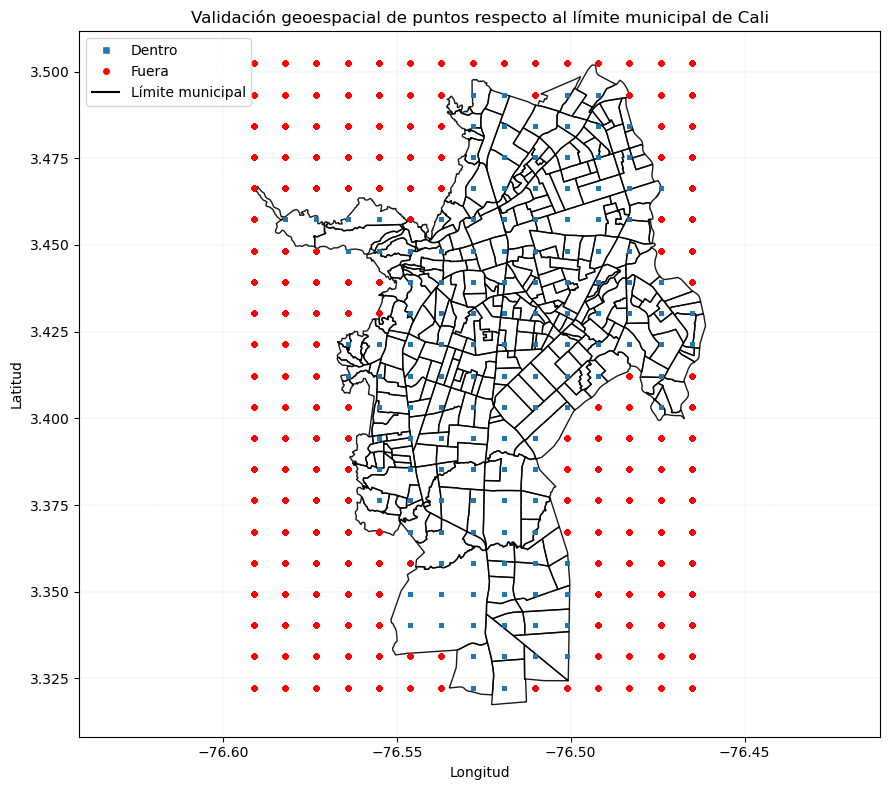

In [15]:


gdf = gpd.GeoDataFrame(df_base.loc[coords_ok], geometry=geo, crs=4326)

fig, ax = plt.subplots(figsize=(9,8))

# Límite municipal
cali.boundary.plot(ax=ax, linewidth=1.0, color="black", alpha=0.9, zorder=1)

# Puntos
gdf[gdf["en_cali"]].plot(ax=ax, markersize=6, alpha=0.85, zorder=2, label="Dentro")
gdf[~gdf["en_cali"]].plot(ax=ax, color="red", markersize=10, alpha=0.9, zorder=3, label="Fuera")

# Leyenda
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='Dentro',
           markerfacecolor='C0', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Fuera',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], color='black', lw=1.5, label='Límite municipal')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True)

ax.set_title("Validación geoespacial de puntos respecto al límite municipal de Cali")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

Análicemos la data resultante sobre los puntos tomados en la ciudad de cali:

In [16]:
df_in.head()

,epi_week,y,x,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,band,slope,...,TP34_8_EDA,TP34_9_EDA,hacinamien,n_arboles,spatial_ref,epi_year,epi_week_number,pixel_id,n_casos,en_cali
26467,2015-01,3.322354,-76.528161,0.552808,30.652468,19.989410,0.140088,8.550988,1,1.120038,...,3.925205,2.355123,2.567901,161.0,0,2015,1,-76.5281613_3.32235379,NaN,True
26468,2015-01,3.322354,-76.519161,0.651281,31.384573,20.714012,0.176705,10.661798,1,0.919628,...,1.814367,1.814367,3.053285,0.0,0,2015,1,-76.5191613_3.32235379,NaN,True
26482,2015-01,3.331354,-76.528161,0.595062,30.974171,20.878101,0.132907,4.781754,1,1.251960,...,23.370132,8.859772,2.592477,38.0,0,2015,1,-76.5281613_3.33135379,0.0,True
26483,2015-01,3.331354,-76.519161,0.742590,31.721544,21.310768,0.157967,9.159213,1,1.022385,...,0.955649,0.382364,3.001930,0.0,0,2015,1,-76.5191613_3.33135379,0.0,True
26484,2015-01,3.331354,-76.510161,0.764307,32.057224,21.775398,0.172648,6.064859,1,0.839562,...,4.974298,3.984579,3.083695,0.0,0,2015,1,-76.5101613_3.33135379,0.0,True


In [17]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72419 entries, 26467 to 190556
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   epi_week                 72419 non-null  object 
 1   y                        72419 non-null  float64
 2   x                        72419 non-null  float64
 3   ndvi                     72141 non-null  float64
 4   tmax_fore                72141 non-null  float64
 5   tmin_fore                72141 non-null  float64
 6   ndwi                     72141 non-null  float64
 7   precip_fore              72419 non-null  float64
 8   band                     72419 non-null  int64  
 9   slope                    72419 non-null  float32
 10  aspect                   72419 non-null  float32
 11  valle                    72419 non-null  float64
 12  cumbre                   72419 non-null  float64
 13  tpi                      72419 non-null  float64
 14  tasa_eb_10000         

El modelo se construira para predecir los brotes por semana en la ciudad de Cali en general, procedemos a agrupar los registros en datos por semana epidemiologica:

In [16]:
df_in.columns

Index(['epi_week', 'y', 'x', 'ndvi', 'tmax_fore', 'tmin_fore', 'ndwi',
       'precip_fore', 'band', 'slope', 'aspect', 'valle', 'cumbre', 'tpi',
       'tasa_eb_10000', 'comercial', 'habitacional', 'industrial',
       'institucional', 'publico', 'suelo_en_transformacion',
       'suelo_no_urbanizable', 'estrato', 'area_humedal_m2',
       'distancia_humed_m', 'area_rio_m2', 'distancia_rio_m',
       'distancia_pozos_m', 'n_pozos', 'TP34_1_EDA', 'TP34_2_EDA',
       'TP34_3_EDA', 'TP34_4_EDA', 'TP34_5_EDA', 'TP34_6_EDA', 'TP34_7_EDA',
       'TP34_8_EDA', 'TP34_9_EDA', 'hacinamien', 'n_arboles', 'spatial_ref',
       'epi_year', 'epi_week_number', 'pixel_id', 'n_casos', 'en_cali'],
      dtype='object')

### 2.4) Agrupación y manejo de variables 

In [18]:
cols = ['ndvi', 'tmax_fore', 'tmin_fore', 'ndwi',
       'precip_fore', 'band', 'slope', 'aspect', 'valle', 'cumbre', 'tpi',
       'tasa_eb_10000', 'comercial', 'habitacional', 'industrial',
       'institucional', 'publico', 'suelo_en_transformacion',
       'suelo_no_urbanizable', 'area_humedal_m2',
       'distancia_humed_m', 'area_rio_m2', 'distancia_rio_m',
       'distancia_pozos_m', 'n_pozos', 'TP34_1_EDA', 'TP34_2_EDA',
       'TP34_3_EDA', 'TP34_4_EDA', 'TP34_5_EDA', 'TP34_6_EDA', 'TP34_7_EDA',
       'TP34_8_EDA', 'TP34_9_EDA', 'hacinamien', 'n_arboles', 'spatial_ref',
       'epi_year', 'epi_week_number', 'n_casos']

- precip_fore: La precipitación acumulada en una semana representa la cantidad total de lluvia disponible para la formación de criaderos de mosquitos. Promediarla diluye los eventos intensos de lluvia, que son precisamente los que influyen en el aumento de focos de reproducción. Por eso, los estudios de entomología y epidemiología (p. ej. Gómez et al., Int. J. Environ. Res. Public Health, 2021) recomiendan trabajar con precipitación acumulada semanal.

- [tmax_fore, tmin_fore,ndvi,ndwi]: Son variables continuas que cambian gradualmente y reflejan condiciones promedio del ambiente. Por ejemplo, la temperatura media semanal afecta la velocidad de maduración del mosquito y del virus, y los índices de vegetación (NDVI, NDWI) son más estables y se interpretan mejor como valores medios.

### Esquema de agregación por semana epidemiológica (Cali)

| **Grupo de variables** | **Agregación** | **Justificación técnica y epidemiológica** | **Ejemplos** |
|---|---|---|---|
| Clima (excepto precipitación) | `mean` | Condiciones promedio semanales (temperatura/vegetación) influyen en el ciclo del vector/virus; la señal es de estado medio. | `tmax_fore`, `tmin_fore`, `ndvi`, `ndwi` |
| Precipitación | `sum` | El acumulado semanal captura el agua total para criaderos y picos de lluvia; el promedio diluye eventos extremos relevantes. | `precip_fore` |
| Topografía | `mean` | Variables casi estáticas; el promedio por semana/zona mantiene la representatividad del relieve. | `band`, `slope`, `aspect`, `tpi`, `valle`, `cumbre` |
| Epidemiología | `sum` (conteos) / *recalcular tasa* si se requiere | Los casos se suman para el total semanal. La tasa solo si comparas zonas con diferentes poblaciones; a nivel ciudad, el conteo absoluto es más informativo. | `n_casos`, `tasa_eb_10000` |
| Uso del suelo | `mean` | Proporciones/porcentajes espaciales relativamente estables; el promedio conserva su significado físico/social. | `comercial`, `habitacional`, `industrial`, `institucional`, `publico`, `suelo_en_transformacion`, `suelo_no_urbanizable` |
| Hidrología | `mean` | Estructura hídrica casi invariante (áreas, distancias, pozos); el promedio resume adecuadamente. | `area_humedal_m2`, `distancia_humed_m`, `area_rio_m2`, `distancia_rio_m`, `n_pozos` |
| Socio-demográficas | `mean` | Densidades/proporciones con variación lenta; el promedio mantiene la estabilidad del perfil socioeconómico. | `TP34_1_EDA`–`TP34_9_EDA`, `hacinamien`, `n_arboles` |

#### De las dos opciones que tenemos para el uso de variables epidemiologicas, nos enfocaremos en `n_casos` para el desarrollo del modelo a nivel de ciudad, ¿Por qué?
- La población total varía poco semana a semana; normalizar no añade señal para detectar brotes.
- Buscamos magnitud del brote (incrementos absolutos), no riesgo relativo entre subzonas.
- Las tasas suavizan picos epidémicos y reducen sensibilidad ante incrementos reales.


In [19]:
agg_dict = {
    # Clima y vegetación
    'ndvi': 'mean',
    'tmax_fore': 'mean',
    'tmin_fore': 'mean',
    'ndwi': 'mean',
    'precip_fore': 'sum',

    # Topografía
    'band': 'mean',
    'slope': 'mean',
    'aspect': 'mean',
    'valle': 'mean',
    'cumbre': 'mean',
    'tpi': 'mean',

    # Epidemiología
    #'tasa_eb_10000': 'mean',
    'n_casos': 'sum',

    # Uso del suelo
    'comercial': 'mean',
    'habitacional': 'mean',
    'industrial': 'mean',
    'institucional': 'mean',
    'publico': 'mean',
    'suelo_en_transformacion': 'mean',
    'suelo_no_urbanizable': 'mean',

    # Hidrología
    'area_humedal_m2': 'mean',
    'distancia_humed_m': 'mean',
    'area_rio_m2': 'mean',
    'distancia_rio_m': 'mean',
    'distancia_pozos_m': 'mean',
    'n_pozos': 'mean',

    # Socio-demográficas
    'TP34_1_EDA': 'mean', 'TP34_2_EDA': 'mean', 'TP34_3_EDA': 'mean',
    'TP34_4_EDA': 'mean', 'TP34_5_EDA': 'mean', 'TP34_6_EDA': 'mean',
    'TP34_7_EDA': 'mean', 'TP34_8_EDA': 'mean', 'TP34_9_EDA': 'mean',
    'hacinamien': 'mean',
    'n_arboles': 'mean',
}

# Agregar por semana epidemiológica
df_weekly = df.groupby('epi_week', as_index=False).agg(agg_dict)

print(df_weekly.shape)
df_weekly


(521, 37)


,epi_week,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,band,slope,aspect,valle,...,TP34_2_EDA,TP34_3_EDA,TP34_4_EDA,TP34_5_EDA,TP34_6_EDA,TP34_7_EDA,TP34_8_EDA,TP34_9_EDA,hacinamien,n_arboles
0,2015-01,0.352111,32.424825,21.749632,0.053146,721.820769,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
1,2015-02,0.158548,31.418689,21.955060,0.130921,5463.223705,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
2,2015-03,0.114773,29.235511,20.996194,0.103212,9073.424929,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
3,2015-04,0.277151,31.374784,21.703477,0.068598,2088.793410,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
4,2015-05,0.163934,30.535987,21.641942,0.182191,9859.362814,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,2024-48,0.211950,30.709995,21.716560,0.078210,2565.716067,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
517,2024-49,0.176885,30.114895,21.502505,0.138692,3769.412229,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
518,2024-50,0.204851,30.412202,21.525882,0.147983,4133.750662,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727
519,2024-51,0.226668,31.391760,21.933145,0.089296,4628.212886,1.0,1.582375,94.382629,12.775656,...,1396.59314,1722.733276,1525.889771,1326.17688,1287.976074,889.584229,500.687012,285.46048,2.437486,2054.844727


In [20]:
df_weekly.isnull().sum()

epi_week                   0
ndvi                       2
tmax_fore                  2
tmin_fore                  2
ndwi                       2
precip_fore                0
band                       0
slope                      0
aspect                     0
valle                      0
cumbre                     0
tpi                        0
n_casos                    0
comercial                  0
habitacional               0
industrial                 0
institucional              0
publico                    0
suelo_en_transformacion    0
suelo_no_urbanizable       0
area_humedal_m2            0
distancia_humed_m          0
area_rio_m2                0
distancia_rio_m            0
distancia_pozos_m          0
n_pozos                    0
TP34_1_EDA                 0
TP34_2_EDA                 0
TP34_3_EDA                 0
TP34_4_EDA                 0
TP34_5_EDA                 0
TP34_6_EDA                 0
TP34_7_EDA                 0
TP34_8_EDA                 0
TP34_9_EDA    

Debido a la baja cantidad de datos nulos, procedemos a interpolar para conservar la  naturalidad de la serie.

In [21]:
df_weekly = df_weekly.interpolate(limit_direction='both')
df_weekly.isnull().sum()

C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\4036844189.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df_weekly = df_weekly.interpolate(limit_direction='both')


epi_week                   0
ndvi                       0
tmax_fore                  0
tmin_fore                  0
ndwi                       0
precip_fore                0
band                       0
slope                      0
aspect                     0
valle                      0
cumbre                     0
tpi                        0
n_casos                    0
comercial                  0
habitacional               0
industrial                 0
institucional              0
publico                    0
suelo_en_transformacion    0
suelo_no_urbanizable       0
area_humedal_m2            0
distancia_humed_m          0
area_rio_m2                0
distancia_rio_m            0
distancia_pozos_m          0
n_pozos                    0
TP34_1_EDA                 0
TP34_2_EDA                 0
TP34_3_EDA                 0
TP34_4_EDA                 0
TP34_5_EDA                 0
TP34_6_EDA                 0
TP34_7_EDA                 0
TP34_8_EDA                 0
TP34_9_EDA    

In [21]:
df_weekly.columns.tolist()

['epi_week',
 'ndvi',
 'tmax_fore',
 'tmin_fore',
 'ndwi',
 'precip_fore',
 'band',
 'slope',
 'aspect',
 'valle',
 'cumbre',
 'tpi',
 'n_casos',
 'comercial',
 'habitacional',
 'industrial',
 'institucional',
 'publico',
 'suelo_en_transformacion',
 'suelo_no_urbanizable',
 'area_humedal_m2',
 'distancia_humed_m',
 'area_rio_m2',
 'distancia_rio_m',
 'distancia_pozos_m',
 'n_pozos',
 'TP34_1_EDA',
 'TP34_2_EDA',
 'TP34_3_EDA',
 'TP34_4_EDA',
 'TP34_5_EDA',
 'TP34_6_EDA',
 'TP34_7_EDA',
 'TP34_8_EDA',
 'TP34_9_EDA',
 'hacinamien',
 'n_arboles']

Procedemos a realizar una exploración general de las variables finales:

In [22]:
display(df_weekly.describe().T)

,count,mean,std,min,25%,50%,75%,max
ndvi,521.0,0.188770,6.133243e-02,0.040884,0.145505,0.185620,0.227990,0.392563
tmax_fore,521.0,31.053233,1.092337e+00,28.428624,30.265097,31.040777,31.836842,33.817236
tmin_fore,521.0,21.699735,3.986129e-01,20.578251,21.427794,21.743464,22.003934,22.508534
ndwi,521.0,0.115306,4.798810e-02,0.014000,0.080224,0.109578,0.143263,0.300944
precip_fore,521.0,6008.016478,4.717111e+03,434.091089,2088.793410,4916.855470,8687.555328,32627.565636
band,521.0,1.000000,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000
slope,521.0,1.582375,0.000000e+00,1.582375,1.582375,1.582375,1.582375,1.582375
aspect,521.0,94.382614,0.000000e+00,94.382629,94.382629,94.382629,94.382629,94.382629
valle,521.0,12.775656,3.556128e-15,12.775656,12.775656,12.775656,12.775656,12.775656
cumbre,521.0,6.889145,8.890320e-16,6.889145,6.889145,6.889145,6.889145,6.889145


In [23]:
# Identificar variables sin variación (std = 0 o valores únicos)

vars_eda = df_weekly.drop(columns=['epi_week']).columns.tolist()
static_vars = [c for c in vars_eda if df_weekly[c].nunique() <= 1 or df_weekly[c].std() == 0]
print(f"Variables estructurales (sin variación): {len(static_vars)}")
print(static_vars)

Variables estructurales (sin variación): 30
['band', 'slope', 'aspect', 'valle', 'cumbre', 'tpi', 'comercial', 'habitacional', 'industrial', 'institucional', 'publico', 'suelo_en_transformacion', 'suelo_no_urbanizable', 'area_humedal_m2', 'distancia_humed_m', 'area_rio_m2', 'distancia_rio_m', 'distancia_pozos_m', 'n_pozos', 'TP34_1_EDA', 'TP34_2_EDA', 'TP34_3_EDA', 'TP34_4_EDA', 'TP34_5_EDA', 'TP34_6_EDA', 'TP34_7_EDA', 'TP34_8_EDA', 'TP34_9_EDA', 'hacinamien', 'n_arboles']


### 2.5) Selección de variables útiles

Al analizar las estadísticas descriptivas de las variables agregadas por semana epidemiológica, se observó que varias presentan desviación estándar nula (std = 0), indicando que son constantes en el tiempo. Estas variables, al no mostrar variabilidad, no aportan información predictiva sobre los cambios semanales en la incidencia de dengue. En consecuencia, excluiremos estas del modelo, conservando únicamente aquellas con variabilidad temporal.



In [24]:
df_util = df_weekly.drop(columns=static_vars)
df_util.shape

(521, 7)

In [25]:
df_util.describe().T

,count,mean,std,min,25%,50%,75%,max
ndvi,521.0,0.188770,0.061332,0.040884,0.145505,0.185620,0.227990,0.392563
tmax_fore,521.0,31.053233,1.092337,28.428624,30.265097,31.040777,31.836842,33.817236
tmin_fore,521.0,21.699735,0.398613,20.578251,21.427794,21.743464,22.003934,22.508534
ndwi,521.0,0.115306,0.047988,0.014000,0.080224,0.109578,0.143263,0.300944
precip_fore,521.0,6008.016478,4717.111285,434.091089,2088.793410,4916.855470,8687.555328,32627.565636
n_casos,521.0,158.209213,234.482893,0.000000,30.000000,62.000000,183.000000,1314.000000


Hagamos una exploración base de punto de partida:

,epi_year,total_casos,promedio_semanal,max_semana
0,2015,7646.0,147.038462,331.0
1,2016,10717.0,206.096154,431.0
2,2017,2072.0,39.846154,118.0
3,2018,876.0,16.846154,33.0
4,2019,1699.0,32.673077,142.0
5,2020,6716.0,126.716981,374.0
6,2021,3116.0,59.923077,126.0
7,2022,1517.0,29.173077,42.0
8,2023,13217.0,254.173077,612.0
9,2024,34851.0,670.211538,1314.0


C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\2060948723.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


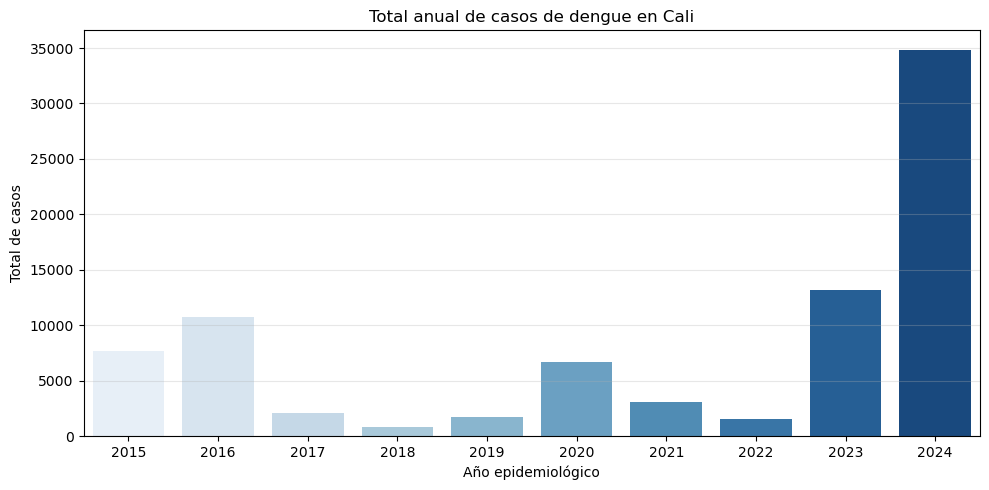

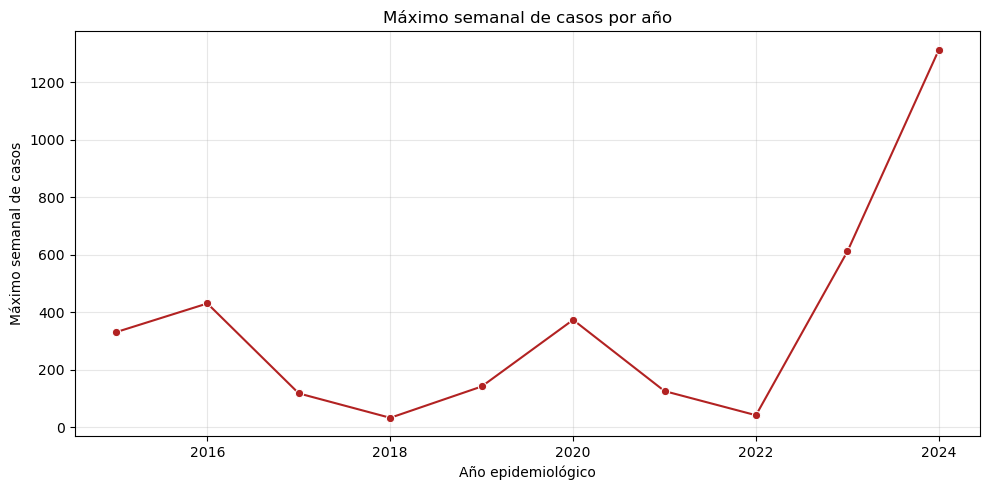

In [26]:
import re

# Extraer solo el año YYYY con regex
tmp = df_util[['epi_week', 'n_casos']].copy()
tmp["epi_year"] = tmp["epi_week"].str.extract(r"(^\d{4})").astype(int)

df_yearly = tmp.groupby("epi_year").agg(
    total_casos=("n_casos", "sum"),
    promedio_semanal=("n_casos", "mean"),
    max_semana=("n_casos", "max")
).reset_index()

display(df_yearly)


# --- Gráfica de totales anuales ---
plt.figure(figsize=(10,5))
sns.barplot(
    data=df_yearly, x="epi_year", y="total_casos",
    palette="Blues", dodge=False
)
plt.title("Total anual de casos de dengue en Cali")
plt.xlabel("Año epidemiológico")
plt.ylabel("Total de casos")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Gráfica de picos anuales ---
plt.figure(figsize=(10,5))
sns.lineplot(data=df_yearly, x="epi_year", y="max_semana",
             marker="o", color="firebrick")
plt.title("Máximo semanal de casos por año")
plt.xlabel("Año epidemiológico")
plt.ylabel("Máximo semanal de casos")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion:**

Se realizó un resumen anual para ver cómo han cambiado los casos de dengue a lo largo del tiempo y detectar los años con mayor actividad. 
El análisis mostró que el dengue en Cali tiene un comportamiento cíclico, con años de muchos casos seguidos por otros de baja transmisión. Los picos más fuertes se presentaron en 2015–2016, 2020 y especialmente en 2023–2024. El brote más grande ocurrió en 2024, con más de 34.000 casos en total y un máximo de 1.314 casos en una sola semana, cifras que superan ampliamente las de años anteriores. 

# 3) EDA:

Procedemos a realizar el EDA y dividirlo en dos principales bloques:

**3.1) Análisis General Descriptivo:** conocer magnitudes, dispersión y relaciones generales entre variables.

**3.2) Análisis de tendencias temporales:** Entender el comportamiento dinámico — cómo evolucionan los factores y los brotes a lo largo del tiempo epidemiológico.

### 3.1) Análisis General Descriptivo

Realicemos un anális descriptivo sobre nuestras variables:

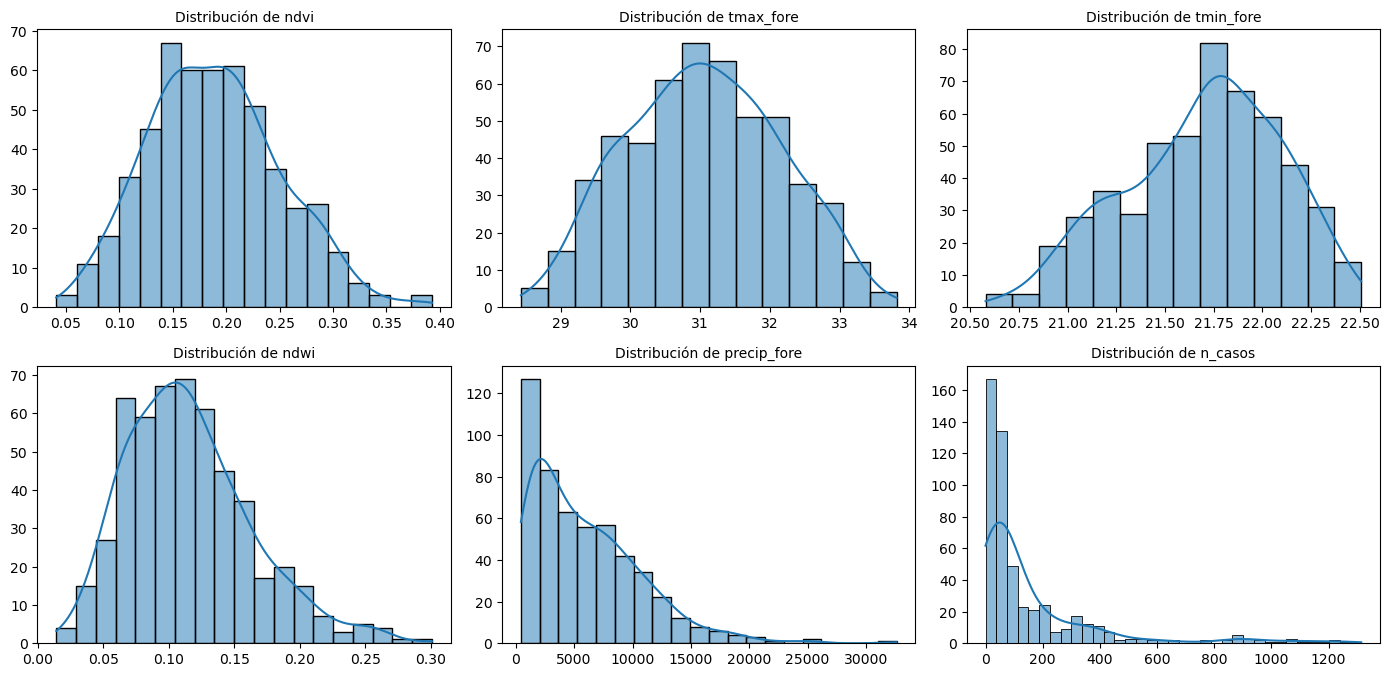

In [27]:

# Obtener variables (excepto epi_week)
vars = df_util.drop(columns="epi_week").columns.tolist()

# Crear figura con subplots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars):
    sns.histplot(df_util[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
# Eliminar subplots vacíos si hay menos de 9 variables
for j in range(len(vars), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


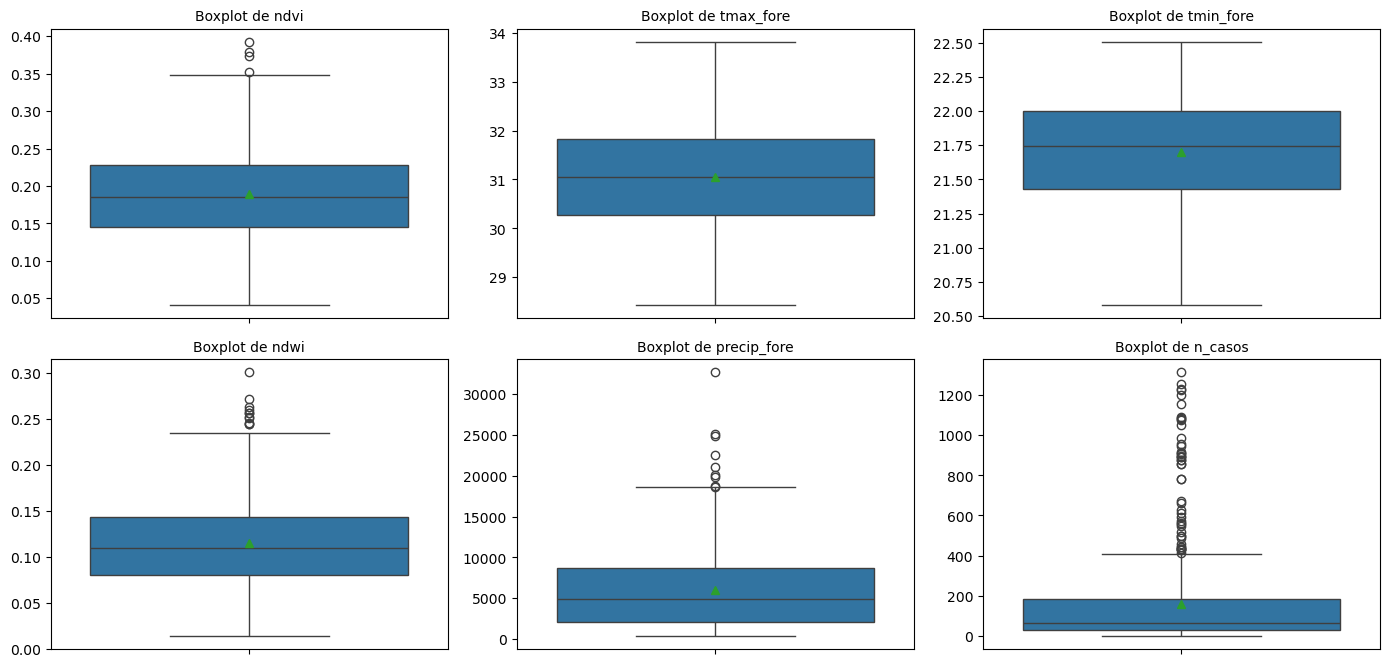

In [28]:
# Variables (excepto epi_week)
vars = df_util.drop(columns="epi_week").columns.tolist()

# Crear figura con subplots
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(vars):
    sns.boxplot(df_util[col], showmeans=True, ax=axes[i])
    axes[i].set_title(f"Boxplot de {col}", fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    
# Eliminar subplots vacíos si hay menos de 9 variables
for j in range(len(vars), 9):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [29]:
df_util.describe().T

,count,mean,std,min,25%,50%,75%,max
ndvi,521.0,0.188770,0.061332,0.040884,0.145505,0.185620,0.227990,0.392563
tmax_fore,521.0,31.053233,1.092337,28.428624,30.265097,31.040777,31.836842,33.817236
tmin_fore,521.0,21.699735,0.398613,20.578251,21.427794,21.743464,22.003934,22.508534
ndwi,521.0,0.115306,0.047988,0.014000,0.080224,0.109578,0.143263,0.300944
precip_fore,521.0,6008.016478,4717.111285,434.091089,2088.793410,4916.855470,8687.555328,32627.565636
n_casos,521.0,158.209213,234.482893,0.000000,30.000000,62.000000,183.000000,1314.000000


#### Conclusiones:
- **ndvi:** oscila entre **0.04 y 0.39**, con media ≈ **0.19** y desviación estándar ≈ **0.06**. Presenta una distribución relativamente simétrica, sin valores extremos significativos, lo que refleja una **cobertura vegetal estable** a lo largo del tiempo.  
- **tmax_fore:** varía entre **28.4 y 33.8 °C**, con media ≈ **31.05 °C** y baja dispersión (std ≈ 1.09). Su forma aproximadamente normal sugiere **condiciones térmicas consistentes**, con ligeras oscilaciones semanales.  
- **tmin_fore:** se mantiene entre **20.6 y 22.5 °C**, con media ≈ **21.70 °C** y std ≈ **0.39**, indicando una **temperatura mínima bastante constante**. 
- **ndwi:** fluctúa entre **0.01 y 0.30**, con media ≈ **0.11** y desviación baja (std ≈ 0.05). La distribución es levemente asimétrica, reflejando **humedad del suelo moderada** y relativamente estable, sin picos abruptos.  
- **precip_fore:** presenta valores entre **434 y 32627 mm**, con media ≈ **6008 mm** y desviación estándar muy alta (≈ 4717). Su distribución es **altamente asimétrica a la derecha**, lo que indica una fuerte concentración de semanas con lluvias bajas y algunos episodios de **precipitaciones extremas**; probar transformaciones o escalado robusto para el modelado.  
- **n_casos:** varía entre **0 y 1314 casos**, con media ≈ **158** y alta desviación (≈ 234). Su distribución es **claramente sesgada a la derecha**, evidenciando largos periodos de baja incidencia y **brotes epidémicos puntuales**. Este patrón es típico de enfermedades vectoriales dependientes del clima, donde las lluvias y el ambiente húmedo actúan como detonantes.

En conjunto, las variables climáticas y de vegetación (`ndvi`, `ndwi`, `tmax_fore`, `tmin_fore`) muestran **comportamientos estables y casi normales**, mientras que `precip_fore` y `n_casos` son **variables de alta variabilidad y comportamiento episódico**. Estas últimas serán clave para el análisis de tendencias y rezagos, dado que sus fluctuaciones extremas están directamente relacionadas con los periodos de brote de dengue.

Análicemos la presencia de datos extremos en nuestras variables:

In [30]:
for col in vars:
    q1, q3 = np.percentile(df_weekly[col].dropna(), [25, 75])
    iqr = q3 - q1
    outliers = df_weekly[(df_weekly[col] < q1 - 1.5*iqr) | (df_weekly[col] > q3 + 1.5*iqr)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df_weekly)*100:.2f}%)")

ndvi: 4 outliers (0.77%)
tmax_fore: 0 outliers (0.00%)
tmin_fore: 0 outliers (0.00%)
ndwi: 11 outliers (2.11%)
precip_fore: 9 outliers (1.73%)
n_casos: 47 outliers (9.02%)


Nuestra variable n_casos(objetivo) presenta una alta presencia de datos extremos, observemos su tendencia para tomar decisiones:

In [31]:
# construir variable temporal de fecha a partir de epi_week

df_util['epi_date'] = pd.to_datetime(df_util['epi_week'] + '-1', format='%G-%V-%u')

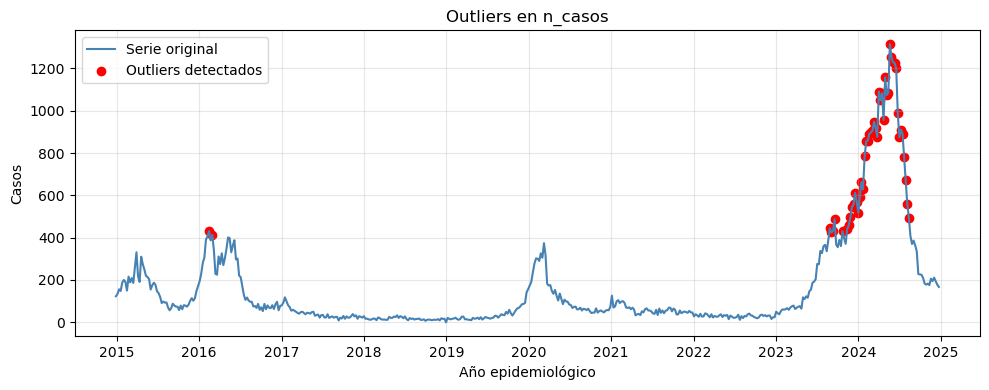

In [34]:
for col in ['n_casos']:
    plt.figure(figsize=(10,4))
    sns.lineplot(x='epi_date', y=col, data=df_util, label='Serie original', color='steelblue')
    
    # Marcar outliers detectados
    q1, q3 = np.percentile(df_util[col].dropna(), [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df_util[(df_util[col] < lower) | (df_util[col] > upper)]
    
    plt.scatter(outliers['epi_date'], outliers[col], color='red', label='Outliers detectados')
    plt.title(f"Outliers en {col}")
    plt.xlabel('Año epidemiológico')
    plt.ylabel("Casos")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

La serie muestra outliers concentrados en los picos epidémicos recientes, no valores aislados ni dispersos.
Los puntos rojos (valores atipicos) no son errores, sino parte del fenómeno natural; brotes epidémicos fuertes.

Los picos se concentran hacia los años más recientes → posible tendencia creciente en la incidencia.
No hay anomalías abruptas fuera del patrón (no hay picos solitarios en periodos sin casos).

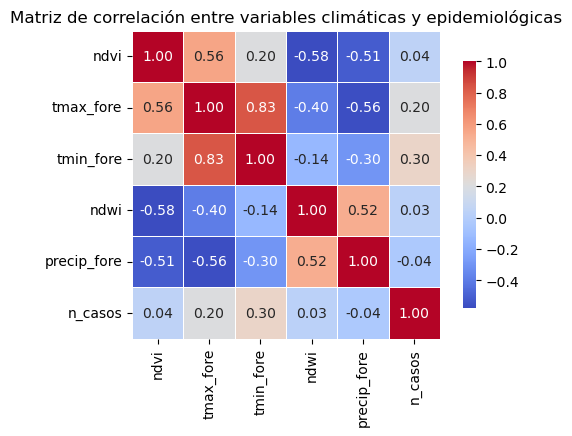

In [35]:
# Calcular matriz de correlación 
corr = df_util.corr(numeric_only=True)

# --- Heatmap de correlaciones ---
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title("Matriz de correlación entre variables climáticas y epidemiológicas", fontsize=12)
plt.show()

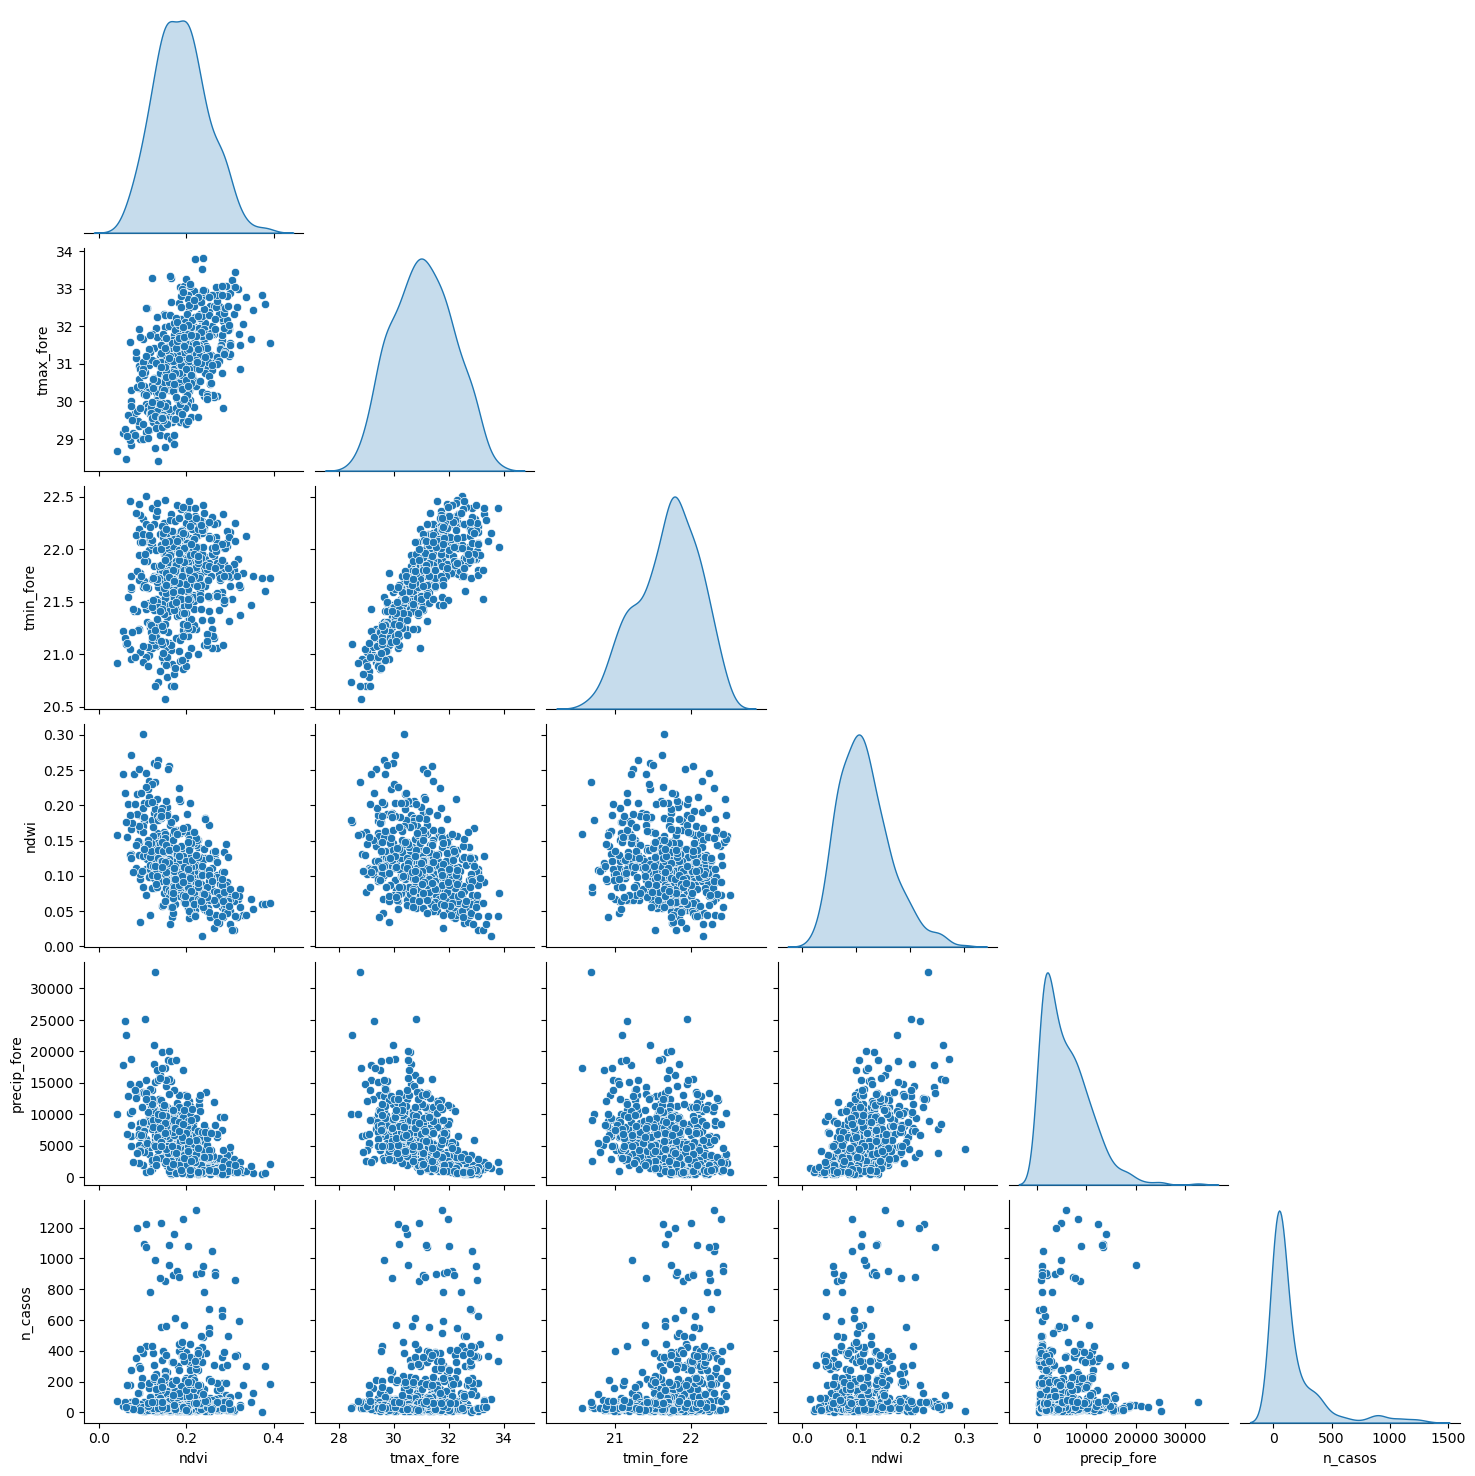

In [36]:
# Pairplot para explorar relaciones visuales
sns.pairplot(df_util, diag_kind='kde', corner=True)
plt.show()

A partir de la matriz de correlación y el análisis visual mediante el pairplot, se identifican las siguientes relaciones clave:

- **tmax_fore y tmin_fore** presentan la **correlación más alta del conjunto (r ≈ 0.83)**, lo que refleja la fuerte relación entre las temperaturas máximas y mínimas semanales. Esto indica una **alta estabilidad térmica** en Cali, donde la amplitud diaria de temperatura es reducida y ambas variables evolucionan en paralelo.  

- **ndvi y ndwi** muestran una **correlación negativa moderada con las variables de temperatura** (`r ≈ -0.40 a -0.58`), lo cual es coherente con la dinámica ambiental: cuando la temperatura aumenta, la vegetación y la humedad superficial tienden a disminuir.  

- **precip_fore** se correlaciona positivamente con `ndwi` (`r ≈ 0.52`) y negativamente con las temperaturas (`r ≈ -0.56` con `tmax_fore`), evidenciando que las semanas lluviosas coinciden con mayor humedad y menor temperatura ambiental.  

- **n_casos**, la variable objetivo, presenta **correlaciones lineales débiles con las variables climáticas (|r| < 0.3)**. Esto confirma que el **efecto del clima sobre los brotes de dengue no es inmediato**, sino que ocurre con **rezagos temporales (lags)**, especialmente respecto a la precipitación.  

El **pairplot** complementa este análisis mostrando nubes de puntos con tendencia débil o difusa entre `n_casos` y las variables climáticas, aunque sí se percibe cierta **acumulación de valores altos de casos** cuando `precip_fore` también presenta valores extremos, lo cual sugiere una relación indirecta que se manifestará con desfase temporal.

En conjunto, las correlaciones reflejan un sistema climático **internamente coherente** (temperaturas y humedad relacionadas) y una influencia **no lineal y retardada** del ambiente sobre la dinámica epidemiológica. Por ello, el siguiente paso será el **análisis de tendencia temporal y estacionalidad**, donde se podrá observar el comportamiento conjunto de las series y sus posibles rezagos.

### 3.2) Análisis de tendencias temporales

In [37]:
df_util = df_util.sort_values('epi_date')
df_util

,epi_week,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,n_casos,epi_date
0,2015-01,0.352111,32.424825,21.749632,0.053146,721.820769,123.0,2014-12-29
1,2015-02,0.158548,31.418689,21.955060,0.130921,5463.223705,134.0,2015-01-05
2,2015-03,0.114773,29.235511,20.996194,0.103212,9073.424929,156.0,2015-01-12
3,2015-04,0.277151,31.374784,21.703477,0.068598,2088.793410,148.0,2015-01-19
4,2015-05,0.163934,30.535987,21.641942,0.182191,9859.362814,188.0,2015-01-26
...,...,...,...,...,...,...,...,...
516,2024-48,0.211950,30.709995,21.716560,0.078210,2565.716067,195.0,2024-11-25
517,2024-49,0.176885,30.114895,21.502505,0.138692,3769.412229,211.0,2024-12-02
518,2024-50,0.204851,30.412202,21.525882,0.147983,4133.750662,195.0,2024-12-09
519,2024-51,0.226668,31.391760,21.933145,0.089296,4628.212886,178.0,2024-12-16


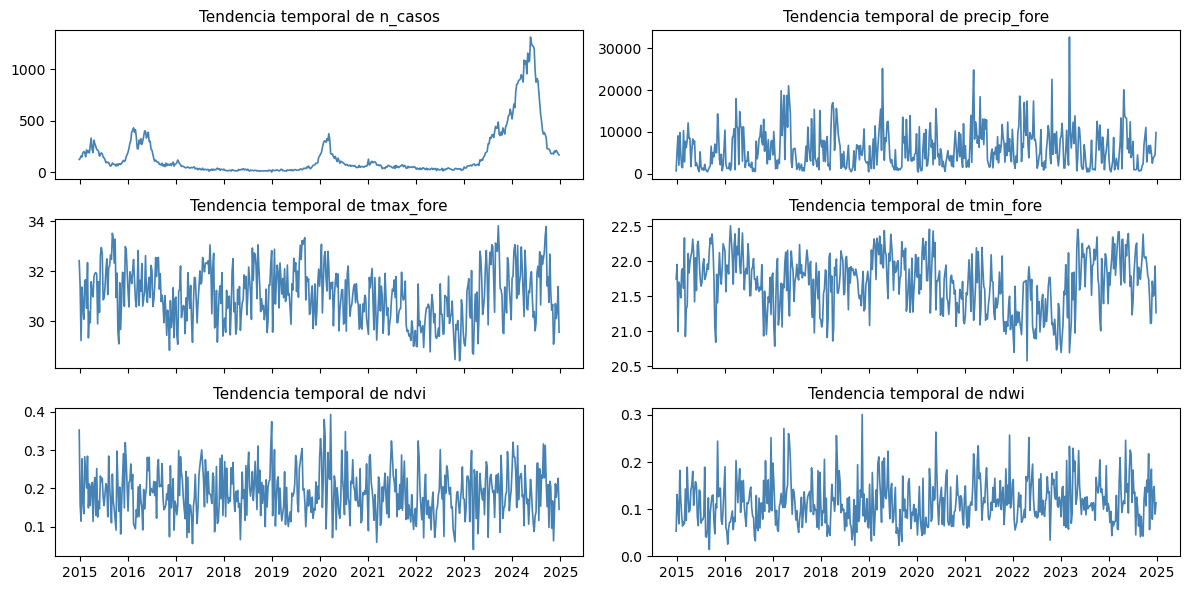

In [38]:

cols = ['n_casos', 'precip_fore', 'tmax_fore', 'tmin_fore', 'ndvi', 'ndwi']

fig, axes = plt.subplots(3, 2, figsize=(12, 6), sharex=True)
axes = axes.ravel()

for i, col in enumerate(cols):
    axes[i].plot(df_util['epi_date'], df_util[col], color='steelblue', linewidth=1.2)
    axes[i].set_title(f"Tendencia temporal de {col}", fontsize=11)
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


### Conclusiones — Tendencias temporales

- **n_casos:** serie con picos epidémicos bien definidos (brotes) y largos periodos de baja incidencia. El gran brote 2023–2024 destaca por magnitud y pendiente de subida.
- **precip_fore:** patrón muy variable con picos intensos y recurrentes; visualmente, los grandes aumentos de precipitación anteceden fases de ascenso en `n_casos` (posible rezago 3–8 semanas).
- **tmax_fore / tmin_fore:** oscilaciones suaves y estables a lo largo de los años; sugieren estacionalidad térmica consistente (amplitud moderada).
- **ndvi / ndwi:** variación suave e interanual, coherente con vegetación/humedad de fondo; sirven como moduladores de condiciones ambientales.
- **Relación visual:** no hay sincronía inmediata entre clima y casos; la señal sugiere **efecto diferido** (lags), especialmente desde `precip_fore` hacia `n_casos`.

Es conveniente suavizar para ver la tendencia subyacente y luego cuantificar rezagos (correlación cruzada) antes del modelado.


C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\4221511140.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


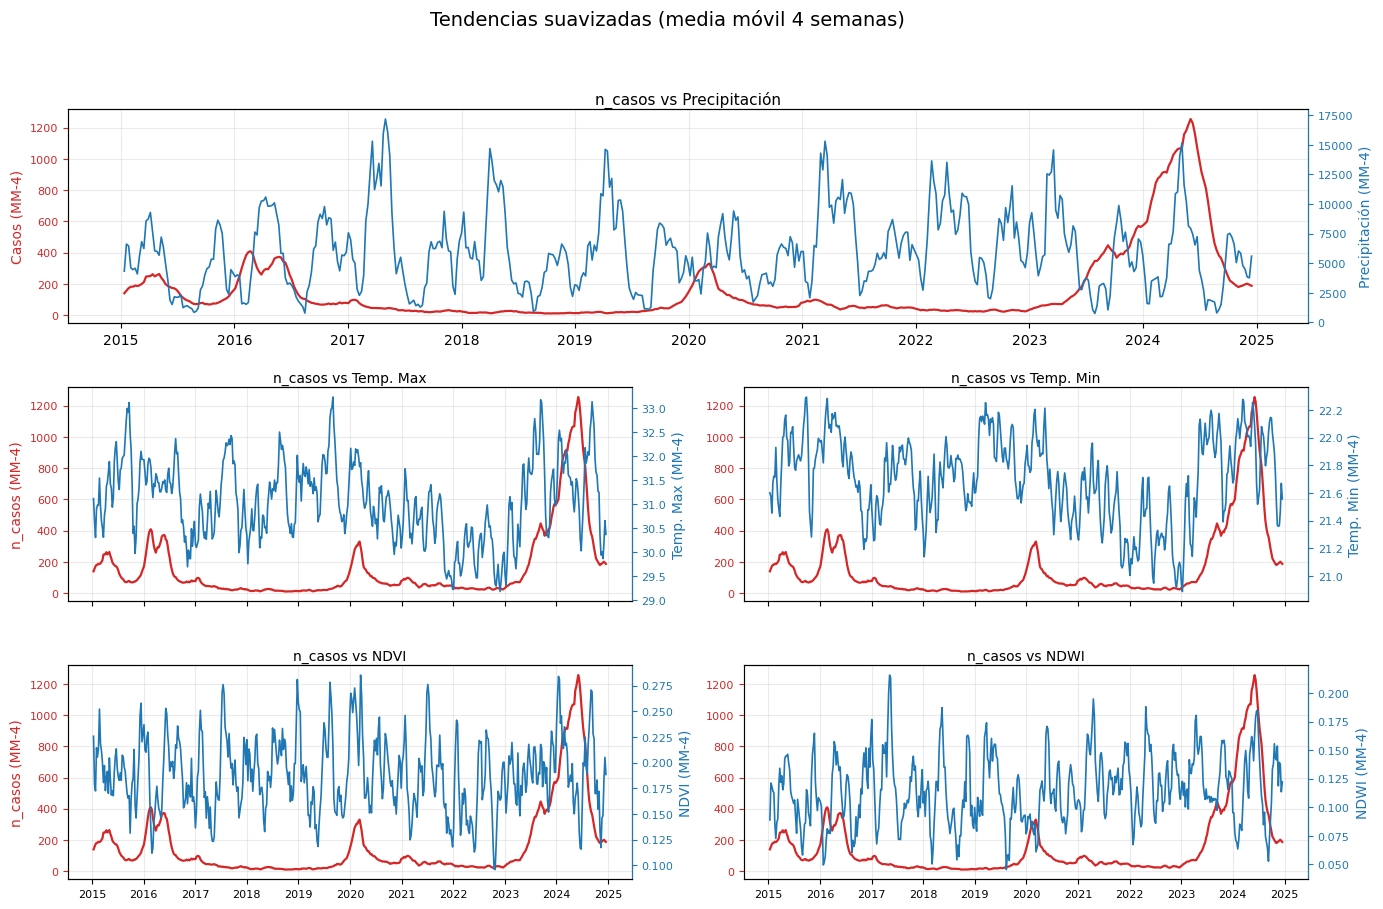

In [39]:
window = 4
dfi = df_util.sort_values('epi_date').set_index('epi_date')

# Variables climáticas a contrastar
vars_to_test = ['precip_fore', 'tmax_fore', 'tmin_fore', 'ndvi', 'ndwi']
titles = {
    'precip_fore': 'Precipitación',
    'tmax_fore':  'Temp. Max',
    'tmin_fore':  'Temp. Min',
    'ndvi':       'NDVI',
    'ndwi':       'NDWI'
}

# Media móvil de n_casos (una sola vez)
casos_mm = dfi['n_casos'].rolling(window, center=True).mean()

# ---- FIGURA Y GRID 3x2 ----
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.2)

# Ajustes de estilo generales
CASE_COLOR = 'tab:red'
CLIMA_COLOR = 'tab:blue'
CASE_LW = 1.6
CLIMA_LW = 1.2

# Para no repetir la misma leyenda en todos los paneles
show_legend_top = False

# ===========================
# 1) Panel grande: Precipitación (fila 0, ambas columnas)
# ===========================
var = 'precip_fore'
clima_mm = dfi[var].rolling(window, center=True).mean()

ax1 = fig.add_subplot(gs[0, :])   # fila 0, columnas 0 y 1

# Eje izquierdo: n_casos
ax1.plot(dfi.index, casos_mm, color=CASE_COLOR, linewidth=CASE_LW, label='Casos')
ax1.set_ylabel('Casos (MM-4)', color=CASE_COLOR)
ax1.tick_params(axis='y', colors=CASE_COLOR, labelsize=8)
ax1.spines['left'].set_color(CASE_COLOR)

# Eje derecho: precipitación
ax1b = ax1.twinx()
ax1b.plot(dfi.index, clima_mm, color=CLIMA_COLOR, linewidth=CLIMA_LW, label=titles[var])
ax1b.set_ylabel(f'{titles[var]} (MM-4)', color=CLIMA_COLOR)
ax1b.tick_params(axis='y', colors=CLIMA_COLOR, labelsize=8)
ax1b.spines['right'].set_color(CLIMA_COLOR)

ax1.set_title(f"n_casos vs {titles[var]}", fontsize=11, pad=4)
ax1.grid(alpha=0.25)

# Leyenda SOLO en el panel principal
if show_legend_top:
    ax1.legend(loc='upper left', fontsize=8, frameon=False)
    ax1b.legend(loc='upper right', fontsize=8, frameon=False)

# Ocultar etiquetas del eje X en la primera fila (para que no sature)
ax1.tick_params(axis='x', labelbottom=True)

# ===========================
# 2) Paneles restantes (2x2)
#    Fila 1: tmax_fore, tmin_fore
#    Fila 2: ndvi, ndwi
# ===========================
other_vars = vars_to_test[1:]  # los otros 4

for i, var in enumerate(other_vars):
    row = 1 + i // 2   # 1 o 2
    col = i % 2        # 0 o 1

    ax = fig.add_subplot(gs[row, col])
    clima_mm = dfi[var].rolling(window, center=True).mean()

    # Casos en rojo (eje izquierdo)
    ax.plot(dfi.index, casos_mm, color=CASE_COLOR, linewidth=CASE_LW)
    # Para no repetir el mismo label en todos los paneles:
    if col == 0:
        ax.set_ylabel('n_casos (MM-4)', color=CASE_COLOR)
    ax.tick_params(axis='y', colors=CASE_COLOR, labelsize=8)
    ax.spines['left'].set_color(CASE_COLOR)

    # Variable climática en azul (eje derecho)
    axb = ax.twinx()
    axb.plot(dfi.index, clima_mm, color=CLIMA_COLOR, linewidth=CLIMA_LW)
    axb.set_ylabel(f'{titles[var]} (MM-4)', color=CLIMA_COLOR)
    axb.tick_params(axis='y', colors=CLIMA_COLOR, labelsize=8)
    axb.spines['right'].set_color(CLIMA_COLOR)

    ax.set_title(f"n_casos vs {titles[var]}", fontsize=10, pad=4)
    ax.grid(alpha=0.25)
    ax.tick_params(axis='x', labelsize=8)

    # Ocultar etiquetas de X en la fila intermedia (solo abajo se leen años)
    if row == 1:
        ax.tick_params(axis='x', labelbottom=False)

# Título global
fig.suptitle("Tendencias suavizadas (media móvil 4 semanas)", fontsize=14, y=0.98)

plt.tight_layout()
plt.show()



El análisis suavizado confirma que ciertos predictores climáticos muestran patrones que anteceden los brotes:

- Precipitación y NDWI aumentan varias semanas antes de los picos de dengue, indicando una relación con rezagos entre 4–8 semanas.
- Temperaturas máx/min presentan variaciones más suaves y consistentes, con señales útiles en rezagos más cortos (1–6 semanas).
- NDVI evoluciona lentamente y sus cambios suelen preceder brotes con rezagos más largos (8–12 semanas).

Estos patrones sugieren que el feature engineering debe incorporar rezagos multihorizonte, medias móviles y acumulados, tanto en las variables climáticas como en la propia serie epidemiológica (n_casos), para capturar:
- rezagos de transmisión.
- Señales previas de crecimiento.
- Efectos estacionales recurrentes.

# 4) Construcción de features

In [40]:

# Configuración 
TARGET = "n_casos"

CLIM_VARS = ["precip_fore", "tmax_fore", "tmin_fore", "ndvi", "ndwi"]

# Plan específico por variable 
TARGET_LAGS       = [1, 2, 3, 4, 6, 8, 12, 52]   # corto, medio y estacional anual
TARGET_MM        = [4, 6, 8, 10, 12]                 # medias móviles
TARGET_ROLL_SUM  = [4, 6, 8]                     # acumulados de casos recientes
TARGET_DIFF_ORD  = [1]                        # delta semanal
TARGET_PCT_CHG   = [1]                        # tasa de crecimiento semanal

CLIMATE_PLAN = {
    "precip_fore": {
        "lags":     [1, 2, 3, 4, 5, 6, 8, 10, 12],
        "mm":       [4, 6, 8],
        "roll_sum": [4, 6, 8],     # lluvia acumulada
        "diff":     [1]         # cambios semanales
    },
    "ndwi": {
        "lags":     [1, 2, 3, 4, 6, 8, 10, 12],
        "mm":       [4, 6, 8],
        "roll_sum": [4, 6, 8]
    },
    "tmax_fore": {
        "lags": [1, 2, 3, 4, 5, 6],
        "mm":   [4, 6],
        "diff": [1]
    },
    "tmin_fore": {
        "lags": [1, 2, 3, 4, 5, 6],
        "mm":   [4, 6],
        "diff": [1]
    },
    "ndvi": {
        "lags": [4, 6, 8, 10, 12],
        "mm":   [4, 6, 8]
    }
}

# ===================== Base temporal =====================
df_feat = df_util.copy()

# Asegura eje temporal semanal como fecha (lunes ISO)
if "epi_date" not in df_feat.columns:
    df_feat["epi_date"] = pd.to_datetime(
        df_feat["epi_week"] + "-1",
        format="%G-%V-%u",
        errors="coerce"
    )

df_feat = df_feat.sort_values("epi_date").set_index("epi_date")

# ===================== Helpers =====================

def add_lags(df, col, lags):
    new_cols = []
    for k in lags:
        nc = f"{col}_lag{k}"
        df[nc] = df[col].shift(k)
        new_cols.append(nc)
    return new_cols

def add_roll_means(df, col, windows, causal=True):
    new_cols = []
    for w in windows:
        nc = f"{col}_mm{w}"
        rm = df[col].rolling(window=w, min_periods=w).mean()
        if causal:
            rm = rm.shift(1)  # hasta la semana anterior
        df[nc] = rm
        new_cols.append(nc)
    return new_cols

def add_roll_sums(df, col, windows, causal=True):
    new_cols = []
    for w in windows:
        nc = f"{col}_cum{w}"
        rs = df[col].rolling(window=w, min_periods=w).sum()
        if causal:
            rs = rs.shift(1)  # acumulado hasta la semana anterior
        df[nc] = rs
        new_cols.append(nc)
    return new_cols

def add_diffs(df, col, orders):
    new_cols = []
    for o in orders:
        nc = f"{col}_diff{o}"
        df[nc] = df[col].diff(o)
        new_cols.append(nc)
    return new_cols

def add_pct_change(df, col, periods):
    new_cols = []
    for p in periods:
        nc = f"{col}_pctchg{p}"
        df[nc] = df[col].pct_change(p)
        new_cols.append(nc)
    return new_cols

# Construcción de features 
created = []

# --- 1) Features del TARGET (n_casos) ---
created += add_lags(df_feat, TARGET, TARGET_LAGS)
created += add_roll_means(df_feat, TARGET, TARGET_MM, causal=True)
created += add_roll_sums(df_feat, TARGET, TARGET_ROLL_SUM, causal=True)
created += add_diffs(df_feat, TARGET, TARGET_DIFF_ORD)
created += add_pct_change(df_feat, TARGET, TARGET_PCT_CHG)

# --- 2) Features climáticas según plan ---
for col, cfg in CLIMATE_PLAN.items():
    if "lags" in cfg:
        created += add_lags(df_feat, col, cfg["lags"])
    if "mm" in cfg:
        created += add_roll_means(df_feat, col, cfg["mm"], causal=True)
    if "roll_sum" in cfg:
        created += add_roll_sums(df_feat, col, cfg["roll_sum"], causal=True)
    if "diff" in cfg:
        created += add_diffs(df_feat, col, cfg["diff"])

# ===================== Post-proceso =====================
# Reemplazar infinitos por NaN (se filtrarán luego)
df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)

# Volver epi_date a columna
df_feat = df_feat.reset_index()

print(f"Total de features creadas: {len(created)}")
print("Ejemplos de columnas creadas:", created[:10])
print("Filas completamente vacías en las nuevas features (por lags/rolling):",
      df_feat[created].isna().all(axis=1).sum())


Total de features creadas: 74
Ejemplos de columnas creadas: ['n_casos_lag1', 'n_casos_lag2', 'n_casos_lag3', 'n_casos_lag4', 'n_casos_lag6', 'n_casos_lag8', 'n_casos_lag12', 'n_casos_lag52', 'n_casos_mm4', 'n_casos_mm6']
Filas completamente vacías en las nuevas features (por lags/rolling): 1


In [41]:
df_feat.head()

,epi_date,epi_week,ndvi,tmax_fore,tmin_fore,ndwi,precip_fore,n_casos,n_casos_lag1,n_casos_lag2,...,tmin_fore_mm6,tmin_fore_diff1,ndvi_lag4,ndvi_lag6,ndvi_lag8,ndvi_lag10,ndvi_lag12,ndvi_mm4,ndvi_mm6,ndvi_mm8
0,2014-12-29,2015-01,0.352111,32.424825,21.749632,0.053146,721.820769,123.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,2015-02,0.158548,31.418689,21.955060,0.130921,5463.223705,134.0,123.0,NaN,...,NaN,0.205427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-12,2015-03,0.114773,29.235511,20.996194,0.103212,9073.424929,156.0,134.0,123.0,...,NaN,-0.958866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-01-19,2015-04,0.277151,31.374784,21.703477,0.068598,2088.793410,148.0,156.0,134.0,...,NaN,0.707283,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015-01-26,2015-05,0.163934,30.535987,21.641942,0.182191,9859.362814,188.0,148.0,156.0,...,NaN,-0.061535,0.352111,NaN,NaN,NaN,NaN,0.225646,NaN,NaN


,Correlación con n_casos
n_casos_mm4,0.972382
n_casos_cum4,0.972382
n_casos_lag1,0.970563
n_casos_lag2,0.967282
n_casos_mm6,0.966646
n_casos_cum6,0.966646
n_casos_cum8,0.960015
n_casos_mm8,0.960015
n_casos_lag3,0.959221
n_casos_mm10,0.953463


C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\3716403424.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corrs['Correlación con n_casos'],


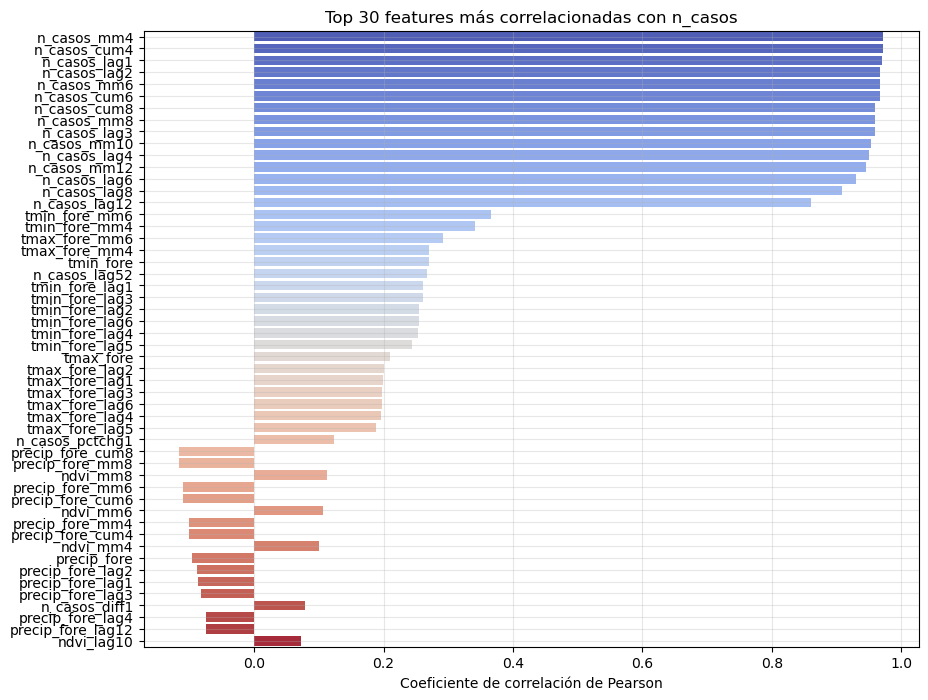

In [42]:
# Garanticemos unciamente columnas numéricas
df_corr = df_feat.select_dtypes(include='number').copy()

# Filtrar solo columnas que contengan n_casos (para evitar redundancia excesiva)
target = 'n_casos'
cols_features = [c for c in df_corr.columns if c != target]

# Calcular correlaciones con la variable objetivo n_casos
corrs = df_corr[cols_features].corrwith(df_corr[target], method='spearman').sort_values(key=abs, ascending=False)

# Mostrar top 30 por magnitud ---
top_corrs = corrs.head(52).to_frame('Correlación con n_casos')
display(top_corrs)

#  Visualización: barras ordenadas ---
plt.figure(figsize=(10,8))
sns.barplot(x=top_corrs['Correlación con n_casos'], 
            y=top_corrs.index, 
            palette='coolwarm', orient='h')
plt.title("Top 30 features más correlacionadas con n_casos")
plt.xlabel("Coeficiente de correlación de Pearson")
plt.ylabel("")
plt.grid(alpha=0.3)
plt.show()


**Conclusión:**
Como parte del análisis exploratorio inicial, se evaluaron las correlaciones lineales entre n_casos y sus transformaciones (lags, medias móviles, acumulados) junto con las variables climáticas. Esto permite identificar relaciones directas y guiar el diseño inicial de features.

Tal como se esperaba, las transformaciones de rezago y suavizamiento de la propia serie de n_casos presentan las correlaciones más altas (autocorrelación). Por su parte, precipitación, humedad y temperatura muestran correlaciones bajas-moderadas, lo cual refuerza la necesidad de utilizar rezagos y acumulados en lugar de valores instantáneos.

,Correlación con n_casos
tmin_fore_mm6,0.366654
tmin_fore_mm4,0.340883
tmax_fore_mm6,0.292358
tmax_fore_mm4,0.270965
tmin_fore,0.270923
tmin_fore_lag1,0.261311
tmin_fore_lag3,0.260940
tmin_fore_lag2,0.255273
tmin_fore_lag6,0.254956
tmin_fore_lag4,0.253230


C:\Users\ingma\AppData\Local\Temp\ipykernel_9656\1332410613.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


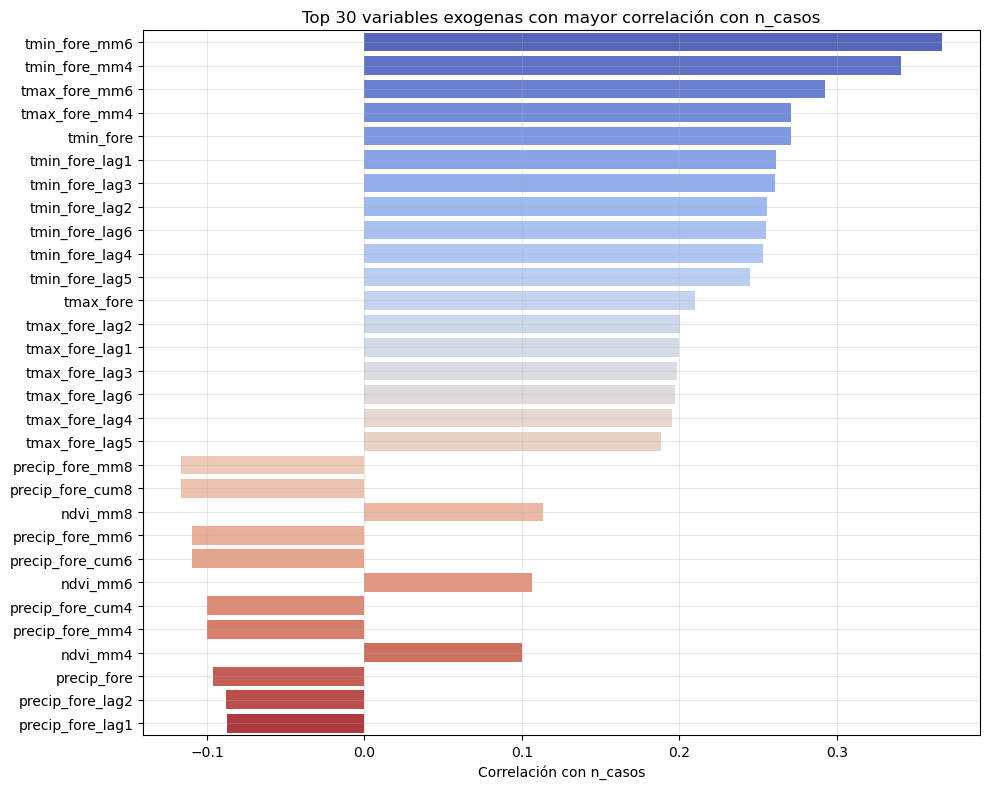

In [43]:

# solo con variables numéricas
df_corr = df_feat.select_dtypes(include='number').copy()


# Excluir todas las columnas basadas en casos
#    (n_casos, n_casos_lagX, n_casos_mmX, etc.)
cols_features_climaticas = [
    c for c in df_corr.columns 
    if not c.startswith("n_casos")
]

# Variable objetivo
interes = "n_casos"

# ================================================
# 3. Calcular correlaciones de Spearman *
# ================================================
corrs_clima = (
    df_corr[cols_features_climaticas]
    .corrwith(df_corr[interes], method='spearman')
    .sort_values(key=abs, ascending=False)
)


top_vars = corrs_clima.head(30).to_frame("Correlación con n_casos")
display(top_vars)

# ================================================
# 4. Visualización
# ================================================
plt.figure(figsize=(10, 8))
sns.barplot(
    x=top_vars["Correlación con n_casos"],
    y=top_vars.index,
    palette='coolwarm',
    orient='h'
)
plt.title("Top 30 variables exogenas con mayor correlación con n_casos")
plt.ylabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Conclusion:**

El análisis de correlación entre las variables ambientales (temperaturas, precipitación y NDVI/NDWI) y los casos semanales de dengue muestra patrones consistentes con la literatura epidemiológica. Entre todas las variables exógenas construidas, las temperaturas mínimas y máximas rezagadas entre 4 y 6 semanas exhiben las correlaciones positivas más altas con la transmisión, sugiriendo un rezago térmico que favorece el ciclo biológico del mosquito Aedes aegypti.

En contraste, las variables asociadas a precipitación acumulada o rezagada muestran correlaciones leves y en su mayoría negativas, lo que indica que su relación con la incidencia del dengue es más compleja y no estrictamente lineal (posibles efectos no lineales, umbrales o saturación hídrica). Los índices de vegetación (NDVI/NDWI) presentan asociaciones muy débiles, lo cual es esperable dado su carácter indirecto como aproximación a humedad y cobertura.

Aunque ninguna variable exógena explica por sí sola grandes proporciones de la variabilidad temporal del dengue, el patrón global confirma que la señal climática relevante está principalmente en las temperaturas, y especialmente cuando se consideran rezagos fisiológicamente coherentes con el ciclo del vector. Estas relaciones justifican plenamente su inclusión como covariables en modelos de predicción y en la formulación de sistemas de alerta temprana.

# 5) Construcción de modelos

El objetivo de este bloque es evaluar diferentes enfoques predictivos para estimar los casos semanales de dengue con un horizonte de cuatro semanas. Para garantizar comparabilidad, todos los modelos —estadísticos, de machine learning y de deep learning— se ajustan bajo el mismo esquema temporal: entrenamiento exclusivamente con información pasada, validación mediante rolling forecast y un test final completamente fuera de muestra.

El bloque se organiza en cinco etapas: Primero, se realiza una breve exploración estadística preliminar orientada a verificar supuestos fundamentales de estacionariedad, estacionalidad y autocorrelación. Luego, se describe la partición temporal utilizada durante el proceso de modelado, fundamentada en la estructura epidemiológica de la serie. Posteriormente, se implementan y evalúan tres familias de modelos:
- modelos estadísticos clásicos
- modelos de aprendizaje automático basados en features climáticas e históricas
- Arquitecturas de deep learning diseñadas para capturar patrones no lineales y dependencias temporales más complejas.

El resultado de este bloque es una comparación integral del desempeño de todas las aproximaciones, bajo un protocolo uniforme, que permite seleccionar el mejor modelo global y reentrenarlo con la información completa para generar el pronóstico final.

### 5.1) Exploración estadística preliminar:
Antes de construir modelos, se realizó una exploración estadística de la serie temporal con el fin de verificar supuestos estructurales y orientar la selección de modelos. Esta etapa incluyó:

- Descomponsición de la serie para separar tendencia, estacionalidad anual y componente de error aleatorio.
- Pruebas de estacionariedad, necesarias para justificar el uso de modelos de la familia ARIMA.
- ACF/PACF, permitió identificar patrones de autocorrelación relevantes y estimar órdenes tentativos (p, d, q).

Aunque posteriormente se emplea auto-arima para seleccionar los parámetros óptimos, esta exploración preliminar aporta evidencia sobre la dinámica temporal del dengue y confirma que la serie requiere diferenciación y captura de memoria de corto plazo.


### 5.1.1) Descomposición de la serie:

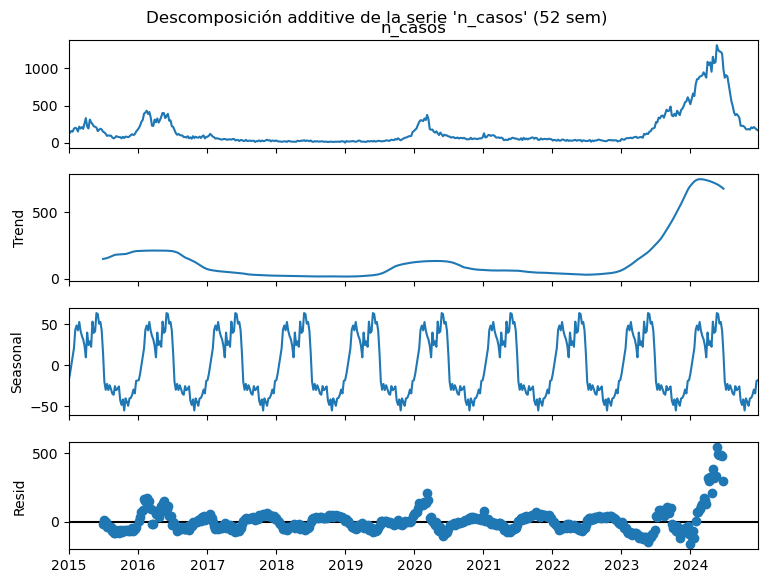

In [ ]:

# Asegurar serie temporal ordenada
serie = df_util.sort_values('epi_date').set_index('epi_date')['n_casos']


# Descomposición multiplicativa o aditiva

# Por presencia de registros en 0, lo ideal es manejar descomposición aditiva
tipo = "additive"  # o "multiplicative"
decomp = seasonal_decompose(serie, model=tipo, period=52)  # 52 semanas ≈ 1 año

# Visualizar ---
fig = decomp.plot()
fig.set_size_inches(8, 6)
fig.suptitle(f"Descomposición {tipo} de la serie 'n_casos' (52 sem)", fontsize=12)
plt.show()


**Conclusiones:** 
- Tendencia: Crecimiento sostenido de casos desde 2022–2023 con un pico epidémico muy alto (2024). Debido a la presencia d euna pendiente positiva la serie sugiere no ser estacionaria.
- Estacionalidad: Ondas anuales bien definidas → el ciclo estacional de dengue está claro (épocas lluviosas).
- Residuales: Incremento de la varianza en los últimos años → los brotes recientes son más intensos y variables.

De las visualizaciones anteriores se observa nula presencia de estacionariedad, sin embargo aseguremos este evento:


### 5.1.2) Pruebas de estacionariedad

In [ ]:

# --- Serie temporal base ---
serie = df_util.sort_values('epi_date').set_index('epi_date')['n_casos']

# --- 1) Prueba ADF (Augmented Dickey-Fuller) ---
resultado_adf = adfuller(serie, autolag='AIC')

print("===== Prueba de estacionariedad (ADF) =====")
print(f"Estadístico ADF: {resultado_adf[0]:.4f}")
print(f"p-value: {resultado_adf[1]:.4f}")
for clave, valor in resultado_adf[4].items():
    print(f"Nivel crítico {clave}: {valor:.4f}")

if resultado_adf[1] < 0.05:
    print("\nLa serie es estacionaria (rechazamos H0).")
else:
    print("\nLa serie NO es estacionaria (no se rechaza H0).")


===== Prueba de estacionariedad (ADF) =====
Estadístico ADF: -2.9192
p-value: 0.0432
Nivel crítico 1%: -3.4432
Nivel crítico 5%: -2.8672
Nivel crítico 10%: -2.5698

La serie es estacionaria (rechazamos H0).


In [ ]:

# Serie temporal base
serie = df_util.sort_values('epi_date').set_index('epi_date')['n_casos']

# --- Prueba de Ljung–Box ---
resultado_box = acorr_ljungbox(serie, lags=[10, 20, 30, 40, 52], return_df=True)
print("===== Prueba de Ljung–Box =====")
print(resultado_box)

# Interpretación
for lag, pvalor in zip(resultado_box.index, resultado_box['lb_pvalue']):
    if pvalor < 0.05:
        print(f"Lag {lag}: la serie presenta autocorrelación (no estacionaria).")
    else:
        print(f"Lag {lag}: no hay autocorrelación significativa (más estacionaria).")


===== Prueba de Ljung–Box =====
        lb_stat  lb_pvalue
10  4438.495209        0.0
20  6886.336568        0.0
30  7907.695034        0.0
40  8322.056800        0.0
52  8471.655348        0.0
Lag 10: la serie presenta autocorrelación (no estacionaria).
Lag 20: la serie presenta autocorrelación (no estacionaria).
Lag 30: la serie presenta autocorrelación (no estacionaria).
Lag 40: la serie presenta autocorrelación (no estacionaria).
Lag 52: la serie presenta autocorrelación (no estacionaria).


===== ADF sobre serie diferenciada (d=1) =====
Estadístico ADF: -5.9684
p-value: 0.0000
Nivel crítico 1%: -3.4432
Nivel crítico 5%: -2.8672
Nivel crítico 10%: -2.5698

La serie diferenciada es estacionaria (rechazamos H₀).


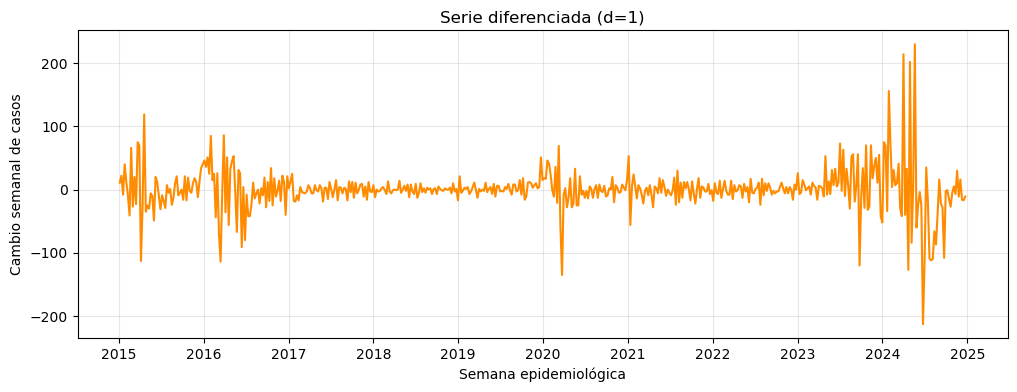

In [47]:
# Diferenciación de primer orden
serie_diff = serie.diff().dropna()

# Prueba ADF sobre serie diferenciada
resultado_adf_diff = adfuller(serie_diff, autolag='AIC')
print("===== ADF sobre serie diferenciada (d=1) =====")
print(f"Estadístico ADF: {resultado_adf_diff[0]:.4f}")
print(f"p-value: {resultado_adf_diff[1]:.4f}")
for k, v in resultado_adf_diff[4].items():
    print(f"Nivel crítico {k}: {v:.4f}")

if resultado_adf_diff[1] < 0.05:
    print("\nLa serie diferenciada es estacionaria (rechazamos H₀).")
else:
    print("\nLa serie diferenciada NO es estacionaria.")

# Visualización
plt.figure(figsize=(12,4))
plt.plot(serie_diff, color='darkorange')
plt.title("Serie diferenciada (d=1)")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Cambio semanal de casos")
plt.grid(alpha=0.3)
plt.show()

**Conclusión:** 
La serie diferencia de primer orden (d=1) es estacionaria.

### 5.1.3) ACF/PACF

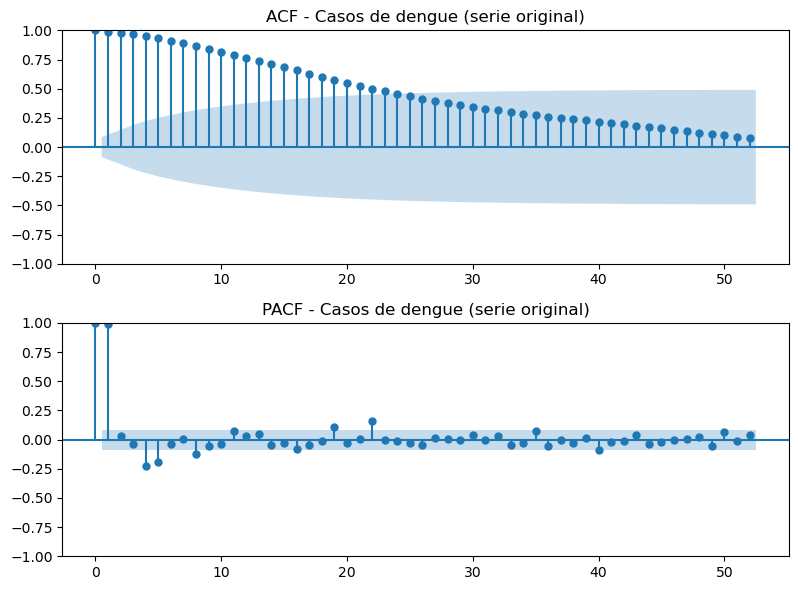

In [ ]:


# Serie temporal ordenada y con índice fecha
serie = df_util.sort_values('epi_date').set_index('epi_date')['n_casos']

fig, ax = plt.subplots(2, 1, figsize=(8,6))

# ACF
plot_acf(serie, lags=52, ax=ax[0])
ax[0].set_title("ACF - Casos de dengue (serie original)")

# PACF
plot_pacf(serie, lags=52, method="ywm", ax=ax[1])
ax[1].set_title("PACF - Casos de dengue (serie original)")

plt.tight_layout()
plt.show()


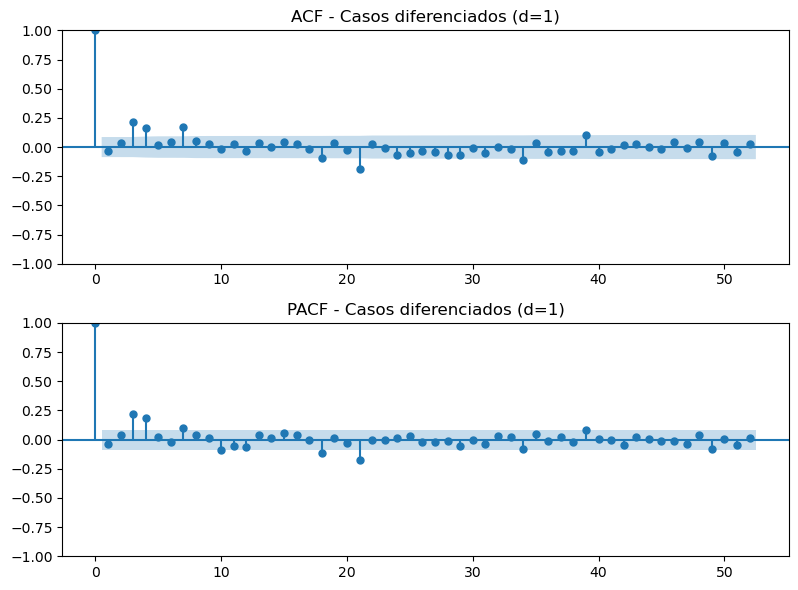

In [49]:
# Serie diferenciada (lag 1)
serie_diff = serie.diff().dropna()

fig, ax = plt.subplots(2, 1, figsize=(8,6))

# ACF
plot_acf(serie_diff, lags=52, ax=ax[0])
ax[0].set_title("ACF - Casos diferenciados (d=1)")

# PACF
plot_pacf(serie_diff, lags=52, method="ywm", ax=ax[1])
ax[1].set_title("PACF - Casos diferenciados (d=1)")

plt.tight_layout()
plt.show()


**Conclusión:**

El análisis conjunto del ACF y el PACF evidencia que la serie semanal de casos de dengue presenta alta autocorrelación y no estacionariedad estructural, evidenciada por la persistencia de correlaciones positivas a lo largo de múltiples rezagos. Tras aplicar una diferenciación de primer orden (d = 1), la serie se estabiliza adecuadamente: la autocorrelación decae rápidamente y el PACF muestra un único pico dominante en el primer rezago.

Esto indica que los modelos autorregresivos necesitan capturar dependencia de corto y mediano plazo y que la diferenciación mínima requerida para ARIMA/SARIMA es consistente con los supuestos teóricos.
Con esta evidencia se procede a definir el esquema de modelado bajo un flujo temporal estricto, evitando fuga de información y garantizando una evaluación realista del desempeño predictivo.

### 5.2) División temporal del conjunto de datos para modelado:

En problemas de predicción epidemiológica, especialmente en series temporales semanales como los casos de dengue, la partición del conjunto de datos debe respetar estrictamente la secuencia temporal. Se debe estructurar una división temporal coherente con la dinámica del fenómeno. Cada observación depende de las anteriores y el modelo solo puede usar información disponible antes del horizonte pronosticado por ello, la serie completa (521 semanas) se esctructura:

1) Data Train: Conformada por las primeras 260 semanas, garantizando:
- Historial suficiente para capturar la tendencia global desde 2015.
- Al menos cinco ciclos estacionales completos (52 semanas).
- Base sólida para derivar lags, medias móviles y acumulados sin riesgo de pérdida masiva de datos iniciales.

Esta fase no se usa para evaluación, sino para configurar los primeros modelos y permitir que la validación rolling tenga un punto de partida estable.

2) Validación rolling expansiva (Walk-forward expanding window):

Las siguientes 108 semanas (≈ 2 años), se evalúan mediante un esquema; **Expanding window + horizonte fijo de 4 semanas**, el procedimiento para cada iteracción es:
- Entrenar con todas las semanas disponibles hasta este punto (expanding window).
- Predecir 4 semanas hacia adelante (h = 4).
- Registrar las métricas.
- Avanzar la frontera de horizonte 4 semanas.
- Repetir hasta cubrir toda la ventana de validación.

Este metodo empleado nos permite:
- Evaluar la estabilidad del modelo en condiciones reales.
- Evitar fuga de información (Data Leakage)
- Comparación de modelos bajo el mismo esquema de pronostico operacional.

*Nota:*  Se emplea este metodo de validación por la razon de que se cuenta con un historico de 10 años de datos y es crítico aprovechar la memoria histórica completa.

3) Data Test: 
Las últimas 4 semanas se reservan exclusivamente para evaluación final. Ningún modelo ve estas observaciones durante entrenamiento o validación.
Este bloque representa el escenario real de implementación: ¿qué tan bien puede el sistema predecir lo que ocurrirá el próximo mes?




### 5.3) Modelos estadísticos:

En este bloque se agrupan los modelos clásicos y modernos de series de tiempo basados en formulaciones estadísticas. Su propósito es capturar patrones estructurales como tendencia, estacionalidad, autocorrelación y dinámicas de corto y mediano plazo, siguiendo estrictamente el esquema temporal definido en la sección 5.2. Los modelos construidos:


- Modelos de Medias Móviles MA(q): Modelo base que captura la dependencia proveniente del error rezagado, útil como referencia comparativa mínima.
- Suavizamiento Exponencial Holt–Winters (ETS): Modelo estructural que combina componentes de nivel, tendencia y estacionalidad anual (52 semanas), adecuado para fenómenos epidemiológicos con ciclos marcados.
- Familia ARIMA (ARIMA, SARIMA, SARIMAX): Modelos autorregresivos integrados que incorporan diferenciación y memoria temporal. SARIMAX extiende la formulación incluyendo variables exógenas climáticas (precipitación, temperatura, NDVI y NDWI), permitiendo evaluar explícitamente su aporte predictivo.
- Prophet (Modelo aditivo estructural): Modelo aditivo basado en descomposición estadística, que representa la tendencia mediante segmentos piecewise, estacionalidades con series de Fourier y capacidad para manejar cambios estructurales. Su diseño robusto y su manejo automático de estacionalidad lo hacen una alternativa sólida frente a los métodos ARIMA tradicionales.

Todos los modelos se evaluaron bajo el mismo esquema de validación rolling forecast de 108 semanas, con un horizonte de predicción de 4 semanas, asegurando comparabilidad rigurosa entre enfoques autorregresivos, estructurales y modelos con variables exógenas.

#### 5.3.1) Modelos de Medias Móviles (MA): 

Los modelos MA(q) representan la formulación más simple dentro de los métodos estadísticos, ya que basan su predicción exclusivamente en la estructura del error rezagado. En este proyecto se evaluaron valores entre q = 1 - 8 como línea base comparativa, permitiendo medir hasta qué punto un modelo mínimo —sin memoria autorregresiva ni componentes estacionales— puede capturar la dinámica de corto plazo de la serie de dengue.

Todas las variantes MA(q) se evaluaron bajo el mismo esquema rolling utilizado en esta sección, garantizando consistencia metodológica.


In [50]:
# Parámetros globales para TODOS los modelos de series de tiempo

H = 4                  # horizonte de predicción (4 semanas)
STEP = 4               # avanzamos 4 semanas en cada iteración de rolling
VAL_WEEKS = 108        # validación sobre ~2 años (108 semanas)
TEST_H = 4             # últimas 4 semanas reservadas como test final


In [51]:

# Serie cruda ordenada por fecha
df_t = df_util.sort_values("epi_date").reset_index(drop=True)
y_raw = df_t["n_casos"].astype(float)

# Transformación log(1 + y) para estabilizar la varianza (se usará en MA)
y = np.log1p(y_raw).astype(float)

N = len(y_raw)

# Índices usados en TODOS los modelos (misma lógica temporal)
test_start = N - TEST_H      # inicio del bloque de test final
N_tv = test_start            # límite de train + validación (todo antes del test)

# Rango para validación rolling (~últimas 108 semanas antes del test)
start_idx = max(260, N_tv - (VAL_WEEKS + H))  
end_idx   = N_tv - H

print(f"N total: {N}")
print(f"Train + Val hasta índice: {N_tv-1}")
print(f"Rolling desde {start_idx} hasta {end_idx} (paso {STEP})")
print(f"Test final: índices {test_start}–{N-1}")


N total: 521
Train + Val hasta índice: 516
Rolling desde 405 hasta 513 (paso 4)
Test final: índices 517–520


In [ ]:


def rmse(a, b):
    """Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(a, b))

def mape(y_true, y_pred):
    """MAPE en porcentaje, con protección ante ceros."""
    eps = 1e-8
    y_true = np.array(y_true, float)
    y_pred = np.array(y_pred, float)
    return 100 * np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps)))

def rolling_eval_MA(q: int) -> pd.DataFrame:
    """
    Valida un modelo MA(q) con esquema rolling forecast:
    - Entrenamiento inicial desde el inicio hasta start_idx
    - En cada iteración se pronostican H semanas
    - Se avanza STEP semanas, actualizando el historial
    Devuelve métricas promedio y tiempo total de validación.
    """
    maes, rmses, mapes = [], [], []
    
    # Historial inicial (en escala log)
    y_hist = y.iloc[:start_idx].copy()
    
    t = start_idx
    iters = 0
    t0 = time.time()
    
    while t <= end_idx:
        iters += 1
        
        # Ajustar MA(q) sobre la serie log-transformada
        model = ARIMA(y_hist, order=(0, 0, q))
        res   = model.fit()
        
        # Predicción en escala log y regreso a escala original
        y_pred_log = res.forecast(steps=H)
        y_pred = np.expm1(y_pred_log)
        
        # Observaciones reales (en escala original)
        y_test_log = y.iloc[t:t+H]
        y_test = np.expm1(y_test_log)
        
        # Métricas en este bloque
        maes.append(np.mean(np.abs(y_test - y_pred)))
        rmses.append(rmse(y_test, y_pred))
        mapes.append(mape(y_test, y_pred))
        
        # Actualizar historial con STEP nuevas observaciones (en log)
        y_hist = pd.concat([y_hist, y.iloc[t:t+STEP]])
        t += STEP
    
    elapsed = time.time() - t0
    
    return pd.DataFrame({
        "Modelo":        [f"MA({q})"],
        "Iter":          [iters],
        "MAE_mean":      [np.mean(maes)],
        "RMSE_mean":     [np.mean(rmses)],
        "MAPE_mean":     [np.mean(mapes)],
        "Tiempo_val_s":  [elapsed]
    })


In [53]:
# Evaluamos MA(q) para q = 1..8 como línea base
resultados_ma = []

for q in range(1, 9):
    df_q = rolling_eval_MA(q)
    resultados_ma.append(df_q)

res_ma = pd.concat(resultados_ma, ignore_index=True)

# Ordenamos por RMSE (de menor a mayor)
res_ma_sorted = res_ma.sort_values("RMSE_mean").reset_index(drop=True)
res_ma_sorted


c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA

,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,MA(8),28,212.849129,227.025656,42.883415,19.235281
1,MA(7),28,249.372662,258.844223,49.594353,17.063653
2,MA(6),28,249.613490,260.624552,47.714954,11.309025
3,MA(5),28,266.651026,277.277133,52.162439,6.939125
4,MA(4),28,289.426708,298.578244,57.505821,5.560636
5,MA(3),28,313.874422,321.681719,61.084676,3.554040
6,MA(2),28,332.348152,338.712662,65.371970,2.510211
7,MA(1),28,354.327969,358.345227,71.045154,1.547126


**Conclusión:**

Los modelos MA(q) permiten evaluar una línea base mínima al capturar únicamente la estructura del error aleatorio en la serie de casos de dengue. En el marco de validación temporal utilizado (rolling forecast, 108 semanas, horizonte de 4 semanas), se observó que el desempeño mejora a medida que aumenta el orden q, con MA(8) como la variante más estable dentro de esta familia.

Sin embargo, incluso su mejor configuración presenta limitaciones: los modelos MA no incorporan tendencia, estacionalidad ni dependencias autorregresivas de la propia serie, aspectos que son relevantes en fenómenos epidemiológicos de tipo cíclico. Por ello, aunque útiles como referencia inicial, estos modelos tienen una capacidad predictiva reducida y deben interpretarse principalmente como un baseline sencillo sobre el cual contrastar métodos más expresivos en etapas posteriores.

### 5.3.2) Suavización exponencial Holt winters

El modelo Holt-Winters (ETS) se emplea como un enfoque estructural capaz de descomponer la serie en nivel, tendencia y estacionalidad sin depender de supuestos autorregresivos. En este caso se utilizó una estacionalidad aditiva de 52 semanas, coherente con la periodicidad anual observada en los casos de dengue.

Siguiendo el mismo esquema temporal utilizado en todo el proyecto —validación rolling forecast, horizonte de 4 semanas y retraining en cada iteración— el objetivo es evaluar qué tan bien un modelo suavizado, basado únicamente en la dinámica interna de la serie, puede anticipar la variación semanal sin apoyo de variables exógenas.

In [54]:
# Serie semanal base para n_casos (escala original, sin log)
y_ets = (
    df_util.sort_values("epi_date")
           .set_index("epi_date")["n_casos"]
           .asfreq("W-MON")        # frecuencia semanal (lunes)
           .interpolate("time")    # por si hubiera algún hueco
           .astype(float)
)

print("N puntos ETS:", len(y_ets))
print("Rango fechas:", y_ets.index.min(), "→", y_ets.index.max())



N puntos ETS: 522
Rango fechas: 2014-12-29 00:00:00 → 2024-12-23 00:00:00


In [55]:
def rolling_ets(
    y: pd.Series,
    seasonal_periods: int = 52,
    H: int = H,
    STEP: int = STEP,
    VAL_WEEKS: int = VAL_WEEKS,
    TEST_H: int = TEST_H
) -> pd.DataFrame:
    """
    Valida un modelo Holt-Winters (ETS aditivo) con esquema rolling forecast,
    usando la misma lógica de ventanas que el resto del proyecto.

    Devuelve un DataFrame con columnas:
    [Modelo, Iter, MAE_mean, RMSE_mean, MAPE_mean, Tiempo_val_s]
    """
    y = y.astype(float).copy()
    N = len(y)

    # Reservamos últimas TEST_H semanas como test final
    test_start = N - TEST_H
    N_tv = test_start

    # Zona de train + validación (últimas VAL_WEEKS se usan para validar)
    start_idx = max(260, N_tv - (VAL_WEEKS + H))   # train inicial razonable
    end_idx   = N_tv - H                           # último inicio posible

    maes, rmses, mapes = [], [], []
    iters = 0
    t0 = time.time()

    for t in range(start_idx, end_idx + 1, STEP):
        iters += 1

        y_train = y.iloc[:t]
        y_val   = y.iloc[t:t + H]

        try:
            # ETS aditivo: nivel + tendencia + estacionalidad
            model = ExponentialSmoothing(
                y_train,
                trend="add",
                seasonal="add",
                seasonal_periods=seasonal_periods
            ).fit(optimized=True)
        except Exception as e:
            # si algo falla en una iteración, la saltamos
            print(f"[ETS] fallo en iter {iters} (t={t}): {e}")
            continue

        # Pronóstico a H semanas
        y_hat = model.forecast(H)

        # Métricas en ese bloque
        maes.append(mean_absolute_error(y_val, y_hat))
        rmses.append(np.sqrt(mean_squared_error(y_val, y_hat)))
        mapes.append(mean_absolute_percentage_error(y_val, y_hat) * 100)  # a %

    elapsed = time.time() - t0

    # Por si alguna razón no se logró evaluar ninguna ventana
    if len(maes) == 0:
        mae_mean  = np.nan
        rmse_mean = np.nan
        mape_mean = np.nan
    else:
        mae_mean  = float(np.mean(maes))
        rmse_mean = float(np.mean(rmses))
        mape_mean = float(np.mean(mapes))

    return pd.DataFrame({
        "Modelo":       ["ETS_add_add"],
        "Iter":         [iters],
        "MAE_mean":     [mae_mean],
        "RMSE_mean":    [rmse_mean],
        "MAPE_mean":    [mape_mean],
        "Tiempo_val_s": [elapsed]
    })


In [56]:
res_ets = rolling_ets(
    y_ets,
    seasonal_periods=52,   # estacionalidad anual
    H=H,
    STEP=STEP,
    VAL_WEEKS=VAL_WEEKS,
    TEST_H=TEST_H
)

res_ets


c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
c:\Users\ingma\anaconda3\

,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,ETS_add_add,28,66.729781,73.95768,23.102294,7.3678


#### 5.3.3) Familia ARIMA (ARIMA, SARIMA Y SARIMAX):

En esta sección se implementan los modelos clásicos de la familia ARIMA, cuya lógica se basa en explicar la serie a partir de sus propios rezagos y de componentes estacionales:
- ARIMA(p, d, q): cCaptura la memoria de corto plazo mediante términos autorregresivos (AR) y de medias móviles (MA) sobre la serie diferenciada (d = 1), tal como se justificó en el análisis ACF–PACF.
- SARIMA(p, d, q)(P,D,Q)_s: extiende ARIMA incluyendo una estructura estacional explícita con periodo semanal anual (s=52), permitiendo modelar la recurrencia anual de los brotes.
- SARIMAX: incorpora, además, variables exógenas climáticas (precipitación, temperatura, NDVI y NDWI) para evaluar si la inclusión de información ambiental mejora la capacidad predictiva frente a los modelos puramente univariados.

Los órdenes (p,d,q) y (P,D,Q,s) se obtienen mediante auto_arima, usando como punto de partida la evidencia de no estacionariedad y memoria de la serie, y todos los modelos se evalúan bajo el mismo esquema de rolling forecast descrito en la sección 5.2 (ventana de 108 semanas, horizonte de 4 semanas), lo que garantiza una comparación justa entre versiones con y sin estacionalidad y con o sin covariables climáticas.


In [ ]:
# ---------- Config ----------
SEASONAL_PERIOD = 52          # semanas ~ 1 año
H = 4                         # horizonte (4 semanas)

TARGET   = "n_casos"
EXOGVARS = ["precip_fore", "tmax_fore", "tmin_fore", "ndvi", "ndwi"]

# ---------- Base ordenada ----------
df = df_util.sort_values("epi_date").copy()

y = df[TARGET].reset_index(drop=True).astype(float)
X = df[EXOGVARS].shift(4).reset_index(drop=True)   # exógenas con lag 4 (sin features masivas)

n = len(df)

# Train / test (últimas H semanas como test simple para auto_arima)
y_tr, y_te = y.iloc[:-H], y.iloc[-H:]
X_tr, X_te = X.iloc[:-H], X.iloc[-H:]

# Métricas
def mae(a, b):  
    return float(np.mean(np.abs(a - b)))

def rmse(a, b): 
    return float(np.sqrt(np.mean((a - b)**2)))

def mape(a, b):
    return float(np.mean(np.abs((a - b) / np.maximum(a, 1e-6))) * 100)


#### 5.3.3.1) Arima

In [58]:
#  ARIMA (sin estacionalidad)
# ==========================
model_arima = pm.auto_arima(
    y_tr,
    seasonal=False,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=1,
    stepwise=True, trace=False,
    error_action='ignore', suppress_warnings=True
)
print("ARIMA seleccionado:")
print(model_arima.summary())
print()




c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_

ARIMA seleccionado:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  517
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2566.578
Date:                Thu, 30 Apr 2026   AIC                           5135.157
Time:                        11:41:29   BIC                           5139.403
Sample:                             0   HQIC                          5136.821
                                - 517                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1224.2747     28.067     43.620      0.000    1169.265    1279.285
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):              3516.10
Prob(Q):                   

#### 5.3.3.2) Sarima (Estacional sin exogenas)

In [59]:
#  SARIMA (estacional, sin exógenas)
# ==========================
model_sarima = pm.auto_arima(
    y_tr,
    seasonal=True, m=SEASONAL_PERIOD,
    start_p=0, max_p=5, start_q=0, max_q=5,
    start_P=0, max_P=2, start_Q=0, max_Q=2,
    d=1, D=0,
    stepwise=True, trace=False,
    error_action='ignore', suppress_warnings=True
)
print("SARIMA seleccionado:")
print(model_sarima.summary())
print()

c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_

SARIMA seleccionado:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  517
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2566.578
Date:                Thu, 30 Apr 2026   AIC                           5135.157
Time:                        11:41:57   BIC                           5139.403
Sample:                             0   HQIC                          5136.821
                                - 517                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1224.2747     28.067     43.620      0.000    1169.265    1279.285
Ljung-Box (L1) (Q):                   0.69   Jarque-Bera (JB):              3516.10
Prob(Q):                  

#### 5.3.3.1) Sarimax (con exogenas)

In [ ]:
#  SARIMAX (estacional + exógenas)
# quitamos filas con NaN en X_tr (por el lag 1 de las exógenas)
valid_idx = X_tr.dropna().index
y_tr_x = y_tr.loc[valid_idx]
X_tr_x = X_tr.loc[valid_idx]

model_sarimax = pm.auto_arima(
    y_tr_x,
    exogenous=X_tr_x,
    seasonal=True, m=SEASONAL_PERIOD,
    start_p=0, max_p=5, start_q=0, max_q=5,
    start_P=0, max_P=2, start_Q=0, max_Q=2,
    d=1, D=0,
    stepwise=True, trace=False,
    error_action='ignore', suppress_warnings=True
)
print("SARIMAX seleccionado:")
print(model_sarimax.summary())



c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_

SARIMAX seleccionado:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  513
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2547.753
Date:                Thu, 30 Apr 2026   AIC                           5097.507
Time:                        11:42:18   BIC                           5101.745
Sample:                             0   HQIC                          5099.168
                                - 513                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      1229.4077     28.307     43.432      0.000    1173.928    1284.888
Ljung-Box (L1) (Q):                   0.70   Jarque-Bera (JB):              3486.68
Prob(Q):                 

Se aprecia un mejor rendimiento en el modelo SARIMAX incluyendo variables exogenas con rezago a 4, realicemos una valdiación más robusta antes de partir como el mejor modelo:

In [61]:
print(f"Ordenes arima{model_arima.order}")
print(f"Ordenes Sarima{model_sarima.order} - {model_sarima.seasonal_order}")
print(f"Ordenes SARIMAX{model_sarimax.order} - {model_sarimax.seasonal_order}")


Ordenes arima(0, 1, 0)
Ordenes Sarima(0, 1, 0) - (0, 0, 0, 52)
Ordenes SARIMAX(0, 1, 0) - (0, 0, 0, 52)


*Nota*: Los tres modelos devolvieron la misma estructura.

Realicemos una validación mas robusta:

In [62]:

# BASE GLOBAL PARA ARIMA-FAMILY

SEASONAL_PERIOD = 52  
# H, STEP, VAL_WEEKS, TEST_H definidos globalmente

TARGET   = "n_casos"
EXOGVARS = ["precip_fore", "tmax_fore", "tmin_fore", "ndvi", "ndwi"]

df_ar = df_util.sort_values("epi_date").reset_index(drop=True)

# Serie objetivo completa
y_all = df_ar[TARGET].astype(float)

# Exógenas rezagadas 1 semana (puedes cambiar a shift(4) si esa fue tu decisión final)
X_all = df_ar[EXOGVARS].shift(1).replace([np.inf, -np.inf], np.nan)

n = len(df_ar)

# Últimas H semanas → test final (no se usan en la validación rolling)
y_te_final = y_all.iloc[-H:]
X_te_final = X_all.iloc[-H:]

# Train+validación = resto
y_tr_all = y_all.iloc[:-H]
X_tr_all = X_all.iloc[:-H]

print("Tamaño total:", n)
print("Train+Val:", len(y_tr_all))
print("Test final:", len(y_te_final))


Tamaño total: 521
Train+Val: 517
Test final: 4


In [ ]:

def rolling_arima_family(
    y: pd.Series,
    X: pd.DataFrame | None,
    order,
    seasonal_order,
    model_name: str,
    H: int = H,
    STEP: int = STEP,
    VAL_WEEKS: int = VAL_WEEKS,
    TEST_H: int = TEST_H
) -> pd.DataFrame:
    """
    Esquema rolling forecast para ARIMA / SARIMA / SARIMAX,
    consistente con el resto de modelos del proyecto.
    """
    y = y.astype(float).copy()
    if X is not None:
        X = X.replace([np.inf, -np.inf], np.nan).copy()

    N = len(y)

    # Reservo últimas TEST_H semanas como test final
    test_start = N - TEST_H
    N_tv = test_start

    # Zona train + validación (últimas VAL_WEEKS para validar)
    start_idx = max(260, N_tv - (VAL_WEEKS + H))
    end_idx   = N_tv - H

    maes, rmses, mapes = [], [], []
    iters = 0
    t0 = time.time()

    for t in range(start_idx, end_idx + 1, STEP):
        iters += 1

        y_train = y.iloc[:t]
        y_val   = y.iloc[t:t+H]

        if X is not None:
            X_train = X.iloc[:t]
            X_val   = X.iloc[t:t+H]

            # limpiamos NaN en train
            mask_train = ~X_train.isna().any(axis=1)
            y_train = y_train.loc[mask_train]
            X_train = X_train.loc[mask_train]

            # si en validación hay NaN, saltamos ese bloque
            if X_val.isna().any().any():
                print(f"[{model_name}] salto iter {iters} (t={t}): NaN en exógenas de validación")
                continue
        else:
            X_train = None
            X_val   = None

        try:
            mod = SARIMAX(
                y_train,
                exog=X_train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = mod.fit(disp=False)
            y_hat = res.forecast(steps=H, exog=X_val)
        except Exception as e:
            print(f"[{model_name}] fallo en iter {iters} (t={t}): {e}")
            continue

        maes.append(mean_absolute_error(y_val, y_hat))
        rmses.append(np.sqrt(mean_squared_error(y_val, y_hat)))
        mapes.append(mean_absolute_percentage_error(y_val, y_hat) * 100)

    elapsed = time.time() - t0

    return pd.DataFrame({
        "Modelo":      [model_name],
        "Iter":        [iters],
        "MAE_mean":    [np.mean(maes) if maes else np.nan],
        "RMSE_mean":   [np.mean(rmses) if rmses else np.nan],
        "MAPE_mean":   [np.mean(mapes) if mapes else np.nan],
        "Tiempo_val_s":[elapsed]
    })


In [64]:
# ARIMA (sin exógenas, sin estacionalidad)
res_arima = rolling_arima_family(
    y=y_all,
    X=None,
    order=model_arima.order,
    seasonal_order=(0, 0, 0, 0),
    model_name="ARIMA"
)

# SARIMA (solo estacionalidad, sin exógenas)
res_sarima = rolling_arima_family(
    y=y_all,
    X=None,
    order=model_sarima.order,
    seasonal_order=model_sarima.seasonal_order,
    model_name="SARIMA"
)

# SARIMAX (con exógenas climáticas rezagadas)
res_sarimax = rolling_arima_family(
    y=y_all,
    X=X_all,
    order=model_sarimax.order,
    seasonal_order=model_sarimax.seasonal_order,
    model_name="SARIMAX"
)

# Tabla resumen
res_arima_family = (
    pd.concat([res_arima, res_sarima, res_sarimax], ignore_index=True)
      .sort_values("RMSE_mean")
)
res_arima_family


c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported i

,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
2,SARIMAX,28,66.767869,74.456731,19.499366,8.219613
0,ARIMA,28,67.080357,74.741224,19.194577,0.318499
1,SARIMA,28,67.080357,74.741224,19.194577,0.297178


**Conclusiones:**

La familia de modelos ARIMA mostró un comportamiento muy estable: ARIMA y SARIMA convergieron prácticamente al mismo ajuste —ambos con orden (0,1,0) y estacionalidad (0,0,0,52)— lo que confirma que la serie requiere una diferenciación (d=1), pero ni la estructura autorregresiva (p) ni la de medias móviles (q) aportan mejoras significativas bajo la dinámica observada.

SARIMAX fue el único modelo que introdujo información adicional útil: al incluir las variables climáticas rezagadas, logró una reducción ligera pero consistente del error (RMSE ≈ 74.45), convirtiéndose en el mejor dentro de la familia. Aunque la ganancia es moderada, evidencia que los predictores exógenos sí contienen señales tempranas relevantes para anticipar los brotes.

# 5.3.4) Prophet

Prophet es un modelo aditivo estructural diseñado para series temporales con estacionalidad marcada y posibles cambios de tendencia. Modela la serie como la suma de tendencia, estacionalidad anual y componentes adicionales, lo que lo convierte en una alternativa flexible frente a ARIMA y ETS.

En este proyecto se incorpora Prophet como un cuarto enfoque estadístico para comparar su capacidad de capturar patrones epidemiológicos semanales bajo el mismo esquema de evaluación utilizado con los demás modelos: entrenamiento estricto sobre datos pasados y validación rolling con horizonte de 4 semanas. De esta forma, su desempeño puede analizarse de manera homogénea dentro del conjunto de modelos estadísticos evaluados.

In [65]:
from prophet import Prophet

# Construir df_prophet (ds, y) con frecuencia semanal 
df_prophet = (
    df_util[['epi_date', 'n_casos']]
    .rename(columns={'epi_date': 'ds', 'n_casos': 'y'})
    .copy()
)

df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Aseguramos semanalidad regular (lunes) y rellenamos huecos pequeños
df_prophet = (
    df_prophet
    .set_index('ds')
    .resample('W-MON')   # lunes = semana epidemiológica
    .sum()
    .interpolate('time')
    .reset_index()
)

df_prophet['y'] = df_prophet['y'].astype(float)

print("Tamaño total Prophet:", len(df_prophet))
df_prophet.head()


Tamaño total Prophet: 522


,ds,y
0,2014-12-29,123.0
1,2015-01-05,134.0
2,2015-01-12,156.0
3,2015-01-19,148.0
4,2015-01-26,188.0


In [ ]:


#  Split para Optuna y test final 
# Últimas TEST_H semanas: test final (NO se usan en Optuna)
df_trainval = df_prophet.iloc[:-TEST_H].copy()
df_test_final_prophet = df_prophet.iloc[-TEST_H:].copy()

# Holdout interno de 4 semanas para Optuna
cutoff_opt = df_trainval['ds'].max() - pd.Timedelta(weeks=4)
train_opt  = df_trainval[df_trainval['ds'] <= cutoff_opt].copy()
test_opt   = df_trainval[df_trainval['ds'] >  cutoff_opt].copy()

print("Filas train_opt:", len(train_opt))
print("Filas test_opt (holdout Optuna):", len(test_opt))

def rmse_np(y, yhat):
    y, yhat = np.array(y, float), np.array(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

# ============= 2.2 Función objetivo para Optuna =============
def objective_prophet(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float(
            "changepoint_prior_scale", 0.001, 0.5, log=True
        ),
        "seasonality_prior_scale": trial.suggest_float(
            "seasonality_prior_scale", 0.01, 10.0, log=True
        ),
        "changepoint_range": trial.suggest_float(
            "changepoint_range", 0.80, 0.95
        ),
        "seasonality_mode": trial.suggest_categorical(
            "seasonality_mode", ["additive", "multiplicative"]
        ),
    }

    m_tmp = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        **params
    )

    # Ajuste en train_opt
    m_tmp.fit(train_opt)

    # Pronosticamos exactamente el tamaño del holdout
    fut_tmp = m_tmp.make_future_dataframe(
        periods=len(test_opt),
        freq='W-MON'
    )
    fcst_tmp = m_tmp.predict(fut_tmp)

    eval_df = (
        test_opt.merge(fcst_tmp[['ds', 'yhat']], on='ds', how='left')
                .dropna()
    )

    if eval_df.empty:
        return 1e9  # penalizamos configuraciones raras

    return rmse_np(eval_df['y'].values, eval_df['yhat'].values)

# Ejecutar estudio Optuna
N_TRIALS  = 30    # reducir si el tiempo tarda mucho
TIMEOUT_S = 300   # o None si solo quieres limitar por número de trials

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective_prophet,
    n_trials=N_TRIALS,
    timeout=TIMEOUT_S,
    n_jobs=1
)

best_prophet_params = study.best_params
print("Mejores hiperparámetros Prophet:")
print(best_prophet_params)
print(f"Mejor RMSE holdout (Optuna): {study.best_value:.2f}")


[I 2026-04-30 11:43:37,309] A new study created in memory with name: no-name-8620ee15-55e2-4f5d-9da2-052a73e969bd
11:43:37 - cmdstanpy - INFO - Chain [1] start processing


Filas train_opt: 514
Filas test_opt (holdout Optuna): 4


11:43:38 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-30 11:43:38,850] Trial 0 finished with value: 186.90200503401243 and parameters: {'changepoint_prior_scale': 0.010253509690168494, 'seasonality_prior_scale': 7.114476009343421, 'changepoint_range': 0.9097990912717108, 'seasonality_mode': 'additive'}. Best is trial 0 with value: 186.90200503401243.
11:43:38 - cmdstanpy - INFO - Chain [1] start processing
11:43:38 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-30 11:43:39,064] Trial 1 finished with value: 50.15976747098514 and parameters: {'changepoint_prior_scale': 0.0026364803038431655, 'seasonality_prior_scale': 0.014936568554617643, 'changepoint_range': 0.9299264218662402, 'seasonality_mode': 'multiplicative'}. Best is trial 1 with value: 50.15976747098514.
11:43:39 - cmdstanpy - INFO - Chain [1] start processing
11:43:39 - cmdstanpy - INFO - Chain [1] done processing
[I 2026-04-30 11:43:39,291] Trial 2 finished with value: 46.5078024270736 and parameters: 

Mejores hiperparámetros Prophet:
{'changepoint_prior_scale': 0.0021348999901951954, 'seasonality_prior_scale': 0.3058656666978526, 'changepoint_range': 0.8051582781672828, 'seasonality_mode': 'additive'}
Mejor RMSE holdout (Optuna): 15.40


In [67]:
def rolling_prophet(
    df_py: pd.DataFrame,
    model_name: str = "Prophet",
    H: int = 4,
    STEP: int = 4,
    VAL_WEEKS: int = 108,
    TEST_H: int = 4,
    prophet_params: dict | None = None,
) -> pd.DataFrame:
    """
    Esquema rolling forecast para Prophet con la misma lógica de ventanas
    que usamos para MA, ETS, ARIMA, ML y DL.
    """
    if prophet_params is None:
        prophet_params = {}

    df_py = df_py.sort_values('ds').reset_index(drop=True).copy()
    N = len(df_py)

    # Reservamos últimas TEST_H semanas como test final
    test_start = N - TEST_H
    N_tv = test_start

    # Zona train + validación (últimas VAL_WEEKS se usan para validar)
    start_idx = max(260, N_tv - (VAL_WEEKS + H))
    end_idx   = N_tv - H

    maes, rmses, mapes = [], [], []
    iters = 0
    t0 = time.time()

    for t in range(start_idx, end_idx + 1, STEP):
        iters += 1

        train_df = df_py.iloc[:t][['ds', 'y']].copy()
        val_df   = df_py.iloc[t:t+H][['ds', 'y']].copy()

        try:
            m = Prophet(
                yearly_seasonality=True,
                weekly_seasonality=False,
                daily_seasonality=False,
                **prophet_params
            )
            m.fit(train_df)

            fut = m.make_future_dataframe(periods=H, freq='W-MON')
            fcst = m.predict(fut).tail(H)

            y_val = val_df['y'].values
            y_hat = fcst['yhat'].values

            maes.append(mean_absolute_error(y_val, y_hat))
            rmses.append(np.sqrt(mean_squared_error(y_val, y_hat)))
            mapes.append(mean_absolute_percentage_error(y_val, y_hat) * 100)

        except Exception as e:
            print(f"[{model_name}] fallo en iter {iters} (t={t}): {e}")
            continue

    elapsed = time.time() - t0

    return pd.DataFrame({
        "Modelo":      [model_name],
        "Iter":        [iters],
        "MAE_mean":    [np.mean(maes) if maes else np.nan],
        "RMSE_mean":   [np.mean(rmses) if rmses else np.nan],
        "MAPE_mean":   [np.mean(mapes) if mapes else np.nan],
        "Tiempo_val_s":[elapsed]
    })

# Ejecutar rolling Prophet con los hiperparámetros óptimos
res_prophet = rolling_prophet(
    df_prophet,
    model_name="Prophet",
    H=H,
    STEP=STEP,
    VAL_WEEKS=VAL_WEEKS,
    TEST_H=TEST_H,
    prophet_params=best_prophet_params
)

res_prophet


11:44:15 - cmdstanpy - INFO - Chain [1] start processing
11:44:15 - cmdstanpy - INFO - Chain [1] done processing
11:44:15 - cmdstanpy - INFO - Chain [1] start processing
11:44:15 - cmdstanpy - INFO - Chain [1] done processing
11:44:16 - cmdstanpy - INFO - Chain [1] start processing
11:44:16 - cmdstanpy - INFO - Chain [1] done processing
11:44:16 - cmdstanpy - INFO - Chain [1] start processing
11:44:16 - cmdstanpy - INFO - Chain [1] done processing
11:44:16 - cmdstanpy - INFO - Chain [1] start processing
11:44:16 - cmdstanpy - INFO - Chain [1] done processing
11:44:16 - cmdstanpy - INFO - Chain [1] start processing
11:44:16 - cmdstanpy - INFO - Chain [1] done processing
11:44:17 - cmdstanpy - INFO - Chain [1] start processing
11:44:17 - cmdstanpy - INFO - Chain [1] done processing
11:44:17 - cmdstanpy - INFO - Chain [1] start processing
11:44:17 - cmdstanpy - INFO - Chain [1] done processing
11:44:17 - cmdstanpy - INFO - Chain [1] start processing
11:44:17 - cmdstanpy - INFO - Chain [1]

,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,Prophet,28,327.107817,330.962584,62.228261,15.519483


**Conclusión:**
Prophet no logró capturar la dinámica epidémica del dengue: su RMSE aproximadamente 331 y MAPE aproximadamente del 62% son muy superiores a los obtenidos por MA, ETS y la familia ARIMA.
Incluso con hiperparámetros optimizados, el modelo no reproduce bien los brotes ni su variabilidad semanal, por lo que queda descartado como candidato competitivo dentro de los modelos estadísticos.

#### 5.3.5) Comparación de modelos estadísticos

In [68]:

# Unir todos los resultados estadísticos
res_estadisticos = pd.concat(
    [
        res_ma,              # MA(1..8)
        res_ets,             # ETS Holt-Winters
        res_arima_family,    # ARIMA, SARIMA, SARIMAX
        res_prophet          # Prophet
    ],
    ignore_index=True
)

# Asegurar el mismo orden de columnas
cols = ["Modelo", "Iter", "MAE_mean", "RMSE_mean", "MAPE_mean", "Tiempo_val_s"]
res_estadisticos = res_estadisticos[cols]

# Ordenar por RMSE (de mejor a peor)
res_estadisticos = (
    res_estadisticos
    .sort_values("RMSE_mean")
    .reset_index(drop=True)
)

res_estadisticos.style.format({
    "MAE_mean": "{:.2f}",
    "RMSE_mean": "{:.2f}",
    "MAPE_mean": "{:.2f}",
    "Tiempo_val_s": "{:.2f}"
})


,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,ETS_add_add,28,66.73,73.96,23.10,7.37
1,SARIMAX,28,66.77,74.46,19.50,8.22
2,SARIMA,28,67.08,74.74,19.19,0.30
3,ARIMA,28,67.08,74.74,19.19,0.32
4,MA(8),28,212.85,227.03,42.88,19.24
5,MA(7),28,249.37,258.84,49.59,17.06
6,MA(6),28,249.61,260.62,47.71,11.31
7,MA(5),28,266.65,277.28,52.16,6.94
8,MA(4),28,289.43,298.58,57.51,5.56
9,MA(3),28,313.87,321.68,61.08,3.55


**Conclusión general - Modelos estadísticos**

El conjunto de modelos evaluados muestra un patrón consistente:
los métodos estructurales (ETS y SARIMAX) superaron ampliamente a los modelos más simples (MA) y al enfoque de Prophet bajo un esquema riguroso de validación rolling, se evidencia:

- ETS (Holt–Winters additivo) obtuvo el mejor desempeño global, con el RMSE más bajo (~73.96) y un MAPE competitivo (~23%), mostrando que la combinación de nivel + tendencia + estacionalidad anual captura bien la dinámica del dengue.
- SARIMAX se ubicó muy cerca, con RMSE ≈ 74.46, siendo el mejor dentro de la familia ARIMA, confirmando que las variables climáticas (rezagadas) aportan información adicional.
- ARIMA y SARIMA tuvieron un rendimiento prácticamente idéntico entre sí (RMSE ≈ 74.7), lo cual indica que la estacionalidad explícita no aportó mejoras claras.
- Los modelos MA(q) quedaron rezagados de forma marcada, funcionando solamente como una línea base débil.
- Prophet fue el modelo con peor ajuste, sin capturar adecuadamente la estructura temporal epidemiológica.



### 5.4) Modelos de Machine Learning

En esta sección incorporamos modelos supervisados clásicos de Machine Learning aplicados a series de tiempo reformuladas como problema de predicción supervisada. A diferencia de los métodos estadísticos del bloque 5.3, estos algoritmos aprenden relaciones no lineales entre los rezagos del objetivo y las variables climáticas, utilizando directamente las features construidas en el bloque anterior.

Todos los modelos se entrenan bajo el mismo esquema rolling forecast con horizonte de 4 semanas, garantizando comparabilidad con ETS, ARIMA/SARIMA/SARIMAX y Prophet.
Los algoritmos evaluados en este bloque incluyen:

- Árboles de decisión como línea base
- Random Forest, robusto ante ruido y no linealidades
- Gradient Boosting / XGBoost / LightGBM, modelos potenciados con capacidad para capturar interacciones complejas

El objetivo es determinar si los modelos de ML logran explotar mejor las relaciones entre clima, memoria epidémica y comportamiento reciente del dengue, en comparación con los enfoques puramente estadísticos.

In [69]:
# ============================================
# 1) Preparación final de features para ML
# ============================================

df_t = df_feat.sort_values("epi_date").reset_index(drop=True).copy()

# Nos quedamos SOLO con columnas numéricas
numeric_cols = df_t.select_dtypes(include=[np.number]).columns.tolist()

# Target
y_all = df_t["n_casos"].to_numpy()

# Features ML = todas menos la variable objetivo
feature_cols_ml = [c for c in numeric_cols if c != "n_casos"]
X_all = df_t[feature_cols_ml].to_numpy()

# Eliminamos cualquier fila con NaN residual
mask = ~np.isnan(X_all).any(axis=1)
X_all = X_all[mask]
y_all = y_all[mask]

print("Total rows ML:", len(y_all))
print("Total features:", len(feature_cols_ml))
print("Ejemplos de features:", feature_cols_ml[:10])


Total rows ML: 468
Total features: 79
Ejemplos de features: ['ndvi', 'tmax_fore', 'tmin_fore', 'ndwi', 'precip_fore', 'n_casos_lag1', 'n_casos_lag2', 'n_casos_lag3', 'n_casos_lag4', 'n_casos_lag6']


In [70]:
# Divisionn de train + validación / test final, coherente con todo el proyecto


N = len(y_all)

TEST_H = 4
test_start = N - TEST_H
test_end   = N

# Train+validación
N_tv = test_start

# Rolling valida solo las últimas 108 semanas
start_idx = max(260, N_tv - (VAL_WEEKS + H))
end_idx   = N_tv - H

print(f"N total: {N}")
print(f"Train+Val hasta índice {N_tv-1}")
print(f"Validación rolling desde {start_idx} hasta {end_idx}")
print(f"Test final desde índice {test_start} a {test_end-1}")


N total: 468
Train+Val hasta índice 463
Validación rolling desde 352 hasta 460
Test final desde índice 464 a 467


In [ ]:
# Rolling evaluation para ML

def rolling_eval_ml(model_name, model_builder):
    maes, rmses, mapes = [], [], []
    t0 = time.time()
    iter_count = 0
    
    t = start_idx
    while t <= end_idx:
        iter_count += 1

        # Train
        X_train = X_all[:t]
        y_train = y_all[:t]

        # Validación H semanas
        X_val = X_all[t:t+H]
        y_val = y_all[t:t+H]

        # Safety: evitamos NaN en alguna ventana
        if np.isnan(X_train).any() or np.isnan(X_val).any():
            print(f"[{model_name}] NaN detectado → se salta iter {iter_count}")
            t += STEP
            continue

        # Entrenar
        model = model_builder()
        model.fit(X_train, y_train)

        # Predecir
        y_hat = model.predict(X_val)

        # Métricas
        mae  = mean_absolute_error(y_val, y_hat)
        rmse = np.sqrt(mean_squared_error(y_val, y_hat))
        mape = float(np.mean(np.abs((y_val - y_hat) / np.maximum(y_val, 1e-6))) * 100)

        maes.append(mae)
        rmses.append(rmse)
        mapes.append(mape)

        t += STEP

    elapsed = time.time() - t0
    
    return pd.Series({
        "Modelo": model_name,
        "Iter": iter_count,
        "MAE_mean": np.mean(maes),
        "RMSE_mean": np.mean(rmses),
        "MAPE_mean": np.mean(mapes),
        "Tiempo_val_s": elapsed
    })


In [72]:

# Modelos ML evaluados


res_list = []

# 1) Random Forest
res_list.append(
    rolling_eval_ml(
        "RandomForest",
        lambda: RandomForestRegressor(
            n_estimators=400,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        )
    )
)

# 2) Gradient Boosting (sklearn)
res_list.append(
    rolling_eval_ml(
        "GradientBoosting",
        lambda: GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    )
)

# 3) XGBoost
res_list.append(
    rolling_eval_ml(
        "XGBoost",
        lambda: XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        )
    )
)

# 4) LightGBM
res_list.append(
    rolling_eval_ml(
        "LightGBM",
        lambda: LGBMRegressor(
            n_estimators=400,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            n_jobs=-1
        )
    )
)

# Consolidar resultados
res_ml = pd.DataFrame(res_list).sort_values("RMSE_mean").reset_index(drop=True)
res_ml


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8933
[LightGBM] [Info] Number of data points in the train set: 352, number of used features: 79
[LightGBM] [Info] Start training from score 74.886364
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9007
[LightGBM] [Info] Number of data points in the train set: 356, number of used features: 79
[LightGBM] [Info] Start training from score 74.359551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9145
[LightGBM] [Info] Number of data points in the train set: 360, number of used features: 79
[LightGBM] [Info] Start training from score 73.877778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11624
[LightGBM] [Info] Number of data points in the train set: 456, number of used features: 79
[LightGBM] [Info] Start training from score 158.888158
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001450 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11707
[LightGBM] [Info] Number of data points in the train set: 460, number of used features: 79
[LightGBM] [Info] Start training from score 159.236957
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,XGBoost,28,59.524227,63.951504,12.035581,6.822274
1,GradientBoosting,28,62.494844,67.872819,12.578537,81.631705
2,RandomForest,28,76.264767,82.751019,16.496160,20.724993
3,LightGBM,28,86.846294,92.630419,15.279978,9.386471


**Conclusiones:**
Tras evaluar cuatro modelos de machine learning bajo un esquema estricto de validación temporal (rolling window con horizonte de 4 semanas), los resultados muestran diferencias claras en desempeño.
- XGBoost: mejor modelo de Machine Learning. Logró el RMSE más bajo (~64) y el MAPE más reducido (~12%), mostrando gran capacidad para capturar relaciones no lineales y patrones rezagados del dengue. También mantuvo un tiempo de validación razonable, por lo que se posiciona como el modelo ML más sólido del experimento.
- Gradient Boosting obtuvo el segundo mejor rendimiento, con errores ligeramente superiores a XGBoost. Aunque más lento computacionalmente, mostró estabilidad y un comportamiento consistente, confirmando que los métodos boosting funcionan bien en series epidemiológicas con alta autocorrelación.
- Random Forest presentó mayor error y variabilidad que los modelos boosting. Captura patrones generales, pero no alcanza la precisión de XGBoost ni Gradient Boosting en horizontes cortos de 4 semanas.
- LightGBM fue eficiente en tiempo, pero no superó a XGBoost ni a Gradient Boosting. Presento un RMSE más alto y menor capacidad para modelar las dinámicas no lineales específicas de la serie.



### 5.5) Modelos de Deep Learning

En esta sección se exploran arquitecturas de Deep Learning orientadas a series de tiempo para pronosticar los casos semanales de dengue. A diferencia de los modelos estadísticos y de Machine Learning clásicos, estas redes neuronales buscan aprender automáticamente representaciones no lineales de la dinámica temporal, potencialmente capturando patrones complejos, interacciones entre rezagos y estructuras de largo plazo. Se emplearon las siguientes arquitecturas:

- MLP (Multilayer Perceptron) aplicado sobre vectores de features rezagadas, como referencia de una red totalmente conectada.
- LSTM (Long Short-Term Memory), diseñada para modelar dependencias de largo plazo mediante estados internos y puertas de memoria.
- TCN (Temporal Convolutional Network), basada en convoluciones causales y dilatadas, que permiten capturar patrones temporales a diferentes escalas de forma eficiente.

Todas las arquitecturas se entrenaron y evaluaron bajo el mismo esquema rolling forecast utilizado en las secciones anteriores: ventanas de entrenamiento crecientes, validación sobre las últimas 108 semanas y horizonte fijo de 4 semanas por delante, evitando fuga de información y permitiendo comparar de forma directa su desempeño frente a los modelos estadísticos y de Machine Learning.


#### 5.5.1) Construccion de MLP

In [ ]:

# Datos para Deep Learning

# Partimos del mismo df_feat usado en ML
df_dl = df_feat.sort_values("epi_date").reset_index(drop=True).copy()

# Nos quedamos solo con columnas numéricas
numeric_cols = df_dl.select_dtypes(include=[np.number]).columns.tolist()

# Variable objetivo
TARGET_COL = "n_casos"
y_all_dl = df_dl[TARGET_COL].to_numpy(dtype=np.float32)

# Features = todas las numéricas menos la variable objetivo
feature_cols_ml = [c for c in numeric_cols if c != TARGET_COL]
X_all_dl = df_dl[feature_cols_ml].to_numpy(dtype=np.float32)

# Eliminar FILAS con NaN (lags, rolling, acumulados, etc.)
mask = ~np.isnan(X_all_dl).any(axis=1)
X_all_dl = X_all_dl[mask]
y_all_dl = y_all_dl[mask]

print("Shape X_all_dl:", X_all_dl.shape)
print("Shape y_all_dl:", y_all_dl.shape)

# ---------------------------
# Índices temporales (mismo esquema global)
# H, STEP, VAL_WEEKS, TEST_H 
# deben estar definidos igual que en ML
# ---------------------------
N_dl = len(y_all_dl)

test_start_dl = N_dl - TEST_H
test_end_dl   = N_dl
N_tv_dl       = test_start_dl

start_idx_dl  = max(260, N_tv_dl - (VAL_WEEKS + H))
end_idx_dl    = N_tv_dl - H

print(f"N total DL: {N_dl}")
print(f"Train+Val hasta índice: {N_tv_dl-1}")
print(f"Rolling validation desde {start_idx_dl} hasta {end_idx_dl} (paso {STEP})")
print(f"Test final desde índice {test_start_dl} hasta {test_end_dl-1}")


Shape X_all_dl: (468, 79)
Shape y_all_dl: (468,)
N total DL: 468
Train+Val hasta índice: 463
Rolling validation desde 352 hasta 460 (paso 4)
Test final desde índice 464 hasta 467


Helper y estructura MLP

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dims=(128, 64), dropout=0.2):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )
    def forward(self, x):
        return self.net(x)


Usando device: cpu


Entrenamiento con parada temprana


In [75]:
def train_mlp(
    X_train, y_train,
    X_val,   y_val,
    epochs=80,
    batch_size=32,
    lr=1e-3,
    patience=10
):
    input_dim = X_train.shape[1]
    model = MLPRegressor(input_dim).to(device)

    train_ds = TabularDataset(X_train, y_train)
    val_ds   = TabularDataset(X_val,   y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = np.inf
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # ---- Valid ----
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = criterion(out, yb)
                val_losses.append(loss.item())
        val_loss = np.mean(val_losses)

        # Early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # Carga el mejor estado
    if best_state is not None:
        model.load_state_dict(best_state)

    # Predicción sobre validación
    model.eval()
    with torch.no_grad():
        y_hat_val = model(torch.from_numpy(X_val).float().to(device)).cpu().numpy().ravel()

    return model, y_hat_val


Validacion

In [76]:
def rolling_eval_mlp():
    maes, rmses, mapes = [], [], []
    iters = 0
    t0_global = time()

    t = start_idx_dl
    while t <= end_idx_dl:
        iters += 1

        # Split temporal (mismo esquema que ML)
        X_train_raw = X_all_dl[:t]
        y_train     = y_all_dl[:t]
        X_val_raw   = X_all_dl[t:t+H]
        y_val       = y_all_dl[t:t+H]

        # Escalado solo con train
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val   = scaler.transform(X_val_raw)

        # Entrenar MLP
        t0 = time()
        _, y_hat_val = train_mlp(
            X_train, y_train,
            X_val,   y_val,
            epochs=80,
            batch_size=32,
            lr=1e-3,
            patience=10
        )
        t1 = time()

        # Métricas
        mae  = mean_absolute_error(y_val, y_hat_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_hat_val))
        mape = float(np.mean(np.abs((y_val - y_hat_val) / np.maximum(y_val, 1e-6))) * 100)

        maes.append(mae); rmses.append(rmse); mapes.append(mape)

        print(f"MLP | iter {iters:2d} – t={t:3d}: MAE={mae:6.2f}  RMSE={rmse:6.2f}  (tiempo {t1-t0:4.1f}s)")

        t += STEP

    t_global = time() - t0_global
    return pd.Series({
        "Modelo": "MLP_PyTorch",
        "Iter": iters,
        "MAE_mean":  np.mean(maes),
        "RMSE_mean": np.mean(rmses),
        "MAPE_mean": np.mean(mapes),
        "Tiempo_val_s": t_global
    })

# Ejecutar validación rolling para MLP
sum_mlp = rolling_eval_mlp()
sum_mlp


MLP | iter  1 – t=352: MAE=  5.25  RMSE=  6.17  (tiempo  2.1s)
MLP | iter  2 – t=356: MAE= 33.25  RMSE= 34.20  (tiempo  0.6s)
MLP | iter  3 – t=360: MAE= 46.09  RMSE= 46.57  (tiempo  0.5s)
MLP | iter  4 – t=364: MAE= 14.59  RMSE= 16.73  (tiempo  0.6s)
MLP | iter  5 – t=368: MAE= 20.17  RMSE= 20.27  (tiempo  2.8s)
MLP | iter  6 – t=372: MAE=  7.68  RMSE=  7.92  (tiempo  2.6s)
MLP | iter  7 – t=376: MAE=  4.75  RMSE=  6.64  (tiempo  2.6s)
MLP | iter  8 – t=380: MAE= 24.46  RMSE= 29.19  (tiempo  2.7s)
MLP | iter  9 – t=384: MAE= 26.01  RMSE= 26.77  (tiempo  2.4s)
MLP | iter 10 – t=388: MAE= 29.37  RMSE= 32.38  (tiempo  2.8s)
MLP | iter 11 – t=392: MAE= 19.86  RMSE= 26.98  (tiempo  2.1s)
MLP | iter 12 – t=396: MAE= 21.50  RMSE= 25.91  (tiempo  1.5s)
MLP | iter 13 – t=400: MAE= 27.88  RMSE= 40.92  (tiempo  1.9s)
MLP | iter 14 – t=404: MAE= 31.77  RMSE= 38.75  (tiempo  3.5s)
MLP | iter 15 – t=408: MAE= 22.39  RMSE= 24.47  (tiempo  1.9s)
MLP | iter 16 – t=412: MAE= 15.38  RMSE= 18.90  (tiempo

Modelo          MLP_PyTorch
Iter                     28
MAE_mean          70.847676
RMSE_mean         76.255565
MAPE_mean         32.541759
Tiempo_val_s      47.830744
dtype: object

#### 5.5.2)Arquitecturas LSTM y TCN

In [ ]:

# 1) Base temporal para DL secuencial
# Partimos del mismo df_feat
df_seq = df_feat.sort_values("epi_date").reset_index(drop=True).copy()

# Variables que alimentan la secuencia (crudas)
seq_cols = ["n_casos", "precip_fore", "tmax_fore", "tmin_fore", "ndvi", "ndwi"]
SEQ_LEN  = 16   # 16 semanas de historia (~4 meses)

S_base = df_seq[seq_cols].to_numpy(dtype=np.float32)   # (N, d)
y_base = df_seq["n_casos"].to_numpy(dtype=np.float32)  # (N,)

N_base  = len(df_seq)

# Índices temporales coherentes con el resto del proyecto
test_start_seq = N_base - TEST_H
test_end_seq   = N_base
N_tv_seq       = test_start_seq

start_idx_seq  = max(260, N_tv_seq - (VAL_WEEKS + H))
end_idx_seq    = N_tv_seq - H

print(f"N total base (secuencial): {N_base}")
print(f"Train+Val hasta índice: {N_tv_seq-1}")
print(f"Rolling validation desde {start_idx_seq} hasta {end_idx_seq} (paso {STEP})")
print(f"Test final desde índice {test_start_seq} hasta {test_end_seq-1}")

# ===========================
# 2) Función para construir secuencias
# ===========================
def build_sequences(S, y, seq_len):
    X_seqs, y_targets, t_idx = [], [], []
    for t in range(seq_len, len(S)):
        X_seqs.append(S[t-seq_len:t, :])  # (seq_len, d)
        y_targets.append(y[t])
        t_idx.append(t)                   # índice temporal real del target
    return (
        np.stack(X_seqs).astype(np.float32),
        np.array(y_targets, dtype=np.float32),
        np.array(t_idx, dtype=np.int32)
    )

X_seq_all, y_seq_all, idx_all = build_sequences(S_base, y_base, SEQ_LEN)

# Por seguridad, quitamos cualquier secuencia con NaN
mask_seq = (~np.isnan(X_seq_all).any(axis=(1, 2))) & (~np.isnan(y_seq_all))
X_seq_all = X_seq_all[mask_seq]
y_seq_all = y_seq_all[mask_seq]
idx_all   = idx_all[mask_seq]

print("X_seq_all:", X_seq_all.shape)  # (N_eff, SEQ_LEN, d)
print("y_seq_all:", y_seq_all.shape)
print("idx_all   (primeros 5):", idx_all[:5])


N total base (secuencial): 521
Train+Val hasta índice: 516
Rolling validation desde 405 hasta 513 (paso 4)
Test final desde índice 517 hasta 520
X_seq_all: (505, 16, 6)
y_seq_all: (505,)
idx_all   (primeros 5): [16 17 18 19 20]


In [ ]:
# Dataset secuencial y modelos DL (LSTM, TCN)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# -------- LSTM --------
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        out, _ = self.lstm(x)
        last = out[:, -1, :]         # estado en el último paso temporal
        return self.fc(last)

# -------- TCN --------
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size
    def forward(self, x):
        return x[:, :, :-self.chomp_size]

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv1d(n_inputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(n_outputs, n_outputs, kernel_size,
                               stride=stride, padding=padding, dilation=dilation)
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.chomp1(out)
        out = self.relu1(out)
        out = self.dropout1(out)

        out = self.conv2(out)
        out = self.chomp2(out)
        out = self.relu2(out)
        out = self.dropout2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class TCNRegressor(nn.Module):
    def __init__(self, input_dim, num_channels=(64, 64), kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            in_ch = input_dim if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            dilation = 2 ** i
            padding = (kernel_size - 1) * dilation
            layers += [TemporalBlock(in_ch, out_ch, kernel_size, stride=1,
                                     dilation=dilation, padding=padding, dropout=dropout)]
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = x.permute(0, 2, 1)      # -> (batch, input_dim, seq_len)
        y = self.tcn(x)             # -> (batch, channels, seq_len)
        last = y[:, :, -1]          # último tiempo
        return self.fc(last)


Device: cpu


Entrenamiento de secuencias

In [79]:
def train_seq_model(
    model,
    X_train, y_train,
    X_val,   y_val,
    epochs=60,
    batch_size=32,
    lr=1e-3,
    patience=8
):
    train_ds = SeqDataset(X_train, y_train)
    val_ds   = SeqDataset(X_val,   y_val)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = np.inf
    best_state = None
    no_improve = 0

    for epoch in range(epochs):
        # --- train ---
        model.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(Xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        # --- val ---
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = criterion(out, yb)
                val_losses.append(loss.item())
        val_loss = np.mean(val_losses)

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = model.state_dict()
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Predicciones en validación
    model.eval()
    with torch.no_grad():
        y_hat_val = model(torch.from_numpy(X_val).float().to(device)).cpu().numpy().ravel()

    return model, y_hat_val


Validacion rolling para LSTM y TCN

In [80]:
def rolling_eval_seq_model(model_name, model_builder):
    maes, rmses, mapes = [], [], []
    iters = 0
    t0_global = time()

    t = start_idx_seq   # índices en escala "original" (0..N_base-1)
    while t <= end_idx_seq:
        # Qué secuencias pertenecen a train/val para este t
        mask_train = idx_all < t
        mask_val   = (idx_all >= t) & (idx_all < t + H)

        if mask_val.sum() == 0:
            break

        X_tr_raw = X_seq_all[mask_train]
        y_tr     = y_seq_all[mask_train]
        X_val_raw = X_seq_all[mask_val]
        y_val     = y_seq_all[mask_val]

        # Escalado por ventana (flatten seq_len)
        scaler = StandardScaler()
        n_tr, L, d = X_tr_raw.shape
        X_tr_2d = X_tr_raw.reshape(n_tr * L, d)
        scaler.fit(X_tr_2d)
        X_tr = scaler.transform(X_tr_2d).reshape(n_tr, L, d)

        n_val = X_val_raw.shape[0]
        X_val_2d = X_val_raw.reshape(n_val * L, d)
        X_val = scaler.transform(X_val_2d).reshape(n_val, L, d)

        # Entrenar modelo en esta ventana
        iters += 1
        t0 = time()
        model = model_builder()
        _, y_hat_val = train_seq_model(
            model,
            X_tr, y_tr,
            X_val, y_val,
            epochs=60,
            batch_size=32,
            lr=1e-3,
            patience=8
        )
        t1 = time()

        mae  = mean_absolute_error(y_val, y_hat_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_hat_val))
        mape = float(np.mean(np.abs((y_val - y_hat_val) / np.maximum(y_val, 1e-6))) * 100)

        maes.append(mae); rmses.append(rmse); mapes.append(mape)

        print(f"{model_name} | iter {iters:2d} t={t:3d}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  ({t1-t0:4.1f}s)")

        t += STEP

    t_global = time() - t0_global
    return pd.Series({
        "Modelo": model_name,
        "Iter": iters,
        "MAE_mean":  np.mean(maes),
        "RMSE_mean": np.mean(rmses),
        "MAPE_mean": np.mean(mapes),
        "Tiempo_val_s": t_global
    })

# Ejecutar LSTM y TCN
sum_lstm = rolling_eval_seq_model(
    "LSTM",
    lambda: LSTMRegressor(input_dim=len(seq_cols), hidden_dim=64, num_layers=1, dropout=0.1)
)

sum_tcn = rolling_eval_seq_model(
    "TCN",
    lambda: TCNRegressor(input_dim=len(seq_cols), num_channels=(64, 64), kernel_size=3, dropout=0.2)
)

sum_lstm, sum_tcn


LSTM | iter  1 t=405  MAE=  7.00  RMSE=  9.22  ( 1.5s)
LSTM | iter  2 t=409  MAE=  5.09  RMSE=  5.56  ( 1.4s)
LSTM | iter  3 t=413  MAE=  6.79  RMSE=  7.94  ( 1.2s)
LSTM | iter  4 t=417  MAE=  5.50  RMSE=  5.99  ( 2.2s)
LSTM | iter  5 t=421  MAE= 15.28  RMSE= 15.52  ( 2.2s)
LSTM | iter  6 t=425  MAE= 22.90  RMSE= 24.15  ( 2.1s)
LSTM | iter  7 t=429  MAE= 22.72  RMSE= 23.27  ( 2.1s)
LSTM | iter  8 t=433  MAE= 55.47  RMSE= 60.04  ( 2.3s)
LSTM | iter  9 t=437  MAE=101.56  RMSE=104.65  ( 3.2s)
LSTM | iter 10 t=441  MAE=186.51  RMSE=190.53  ( 3.6s)
LSTM | iter 11 t=445  MAE=297.40  RMSE=297.83  ( 3.3s)
LSTM | iter 12 t=449  MAE=348.04  RMSE=350.47  ( 3.4s)
LSTM | iter 13 t=453  MAE=359.35  RMSE=363.24  ( 3.5s)
LSTM | iter 14 t=457  MAE=342.59  RMSE=343.50  ( 3.3s)
LSTM | iter 15 t=461  MAE=390.98  RMSE=393.60  ( 3.4s)
LSTM | iter 16 t=465  MAE=519.26  RMSE=519.86  ( 3.5s)
LSTM | iter 17 t=469  MAE=546.28  RMSE=548.88  ( 3.6s)
LSTM | iter 18 t=473  MAE=790.91  RMSE=791.86  ( 4.0s)
LSTM | ite

(Modelo                LSTM
 Iter                    28
 MAE_mean        375.740014
 RMSE_mean       378.345689
 MAPE_mean        69.850274
 Tiempo_val_s     83.195416
 dtype: object,
 Modelo                 TCN
 Iter                    28
 MAE_mean         95.529764
 RMSE_mean       103.606082
 MAPE_mean        30.166538
 Tiempo_val_s     78.975654
 dtype: object)

In [81]:
res_dl = pd.concat(
    [pd.Series(sum_mlp), pd.Series(sum_lstm), pd.Series(sum_tcn)],
    axis=1
).T.reset_index(drop=True)

res_dl.sort_values("RMSE_mean")


,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,MLP_PyTorch,28,70.847676,76.255565,32.541759,47.830744
2,TCN,28,95.529764,103.606082,30.166538,78.975654
1,LSTM,28,375.740014,378.345689,69.850274,83.195416


**Conclusiones:**
- MLP_PyTorch: Es la mejor red de las tres en términos de RMSE, capturando razonablemente bien la dinámica, aunque con error mayor que los mejores modelos de ML y estadísticos.
- TCN: Peor RMSE que el MLP, pero mejor MAPE (menos error relativo porcentual), sugiriendo que la red tiende a equivocarse más en magnitud absoluta en picos grandes, pero mantiene proporcionado el error relativo.
- LSTM: Desempeño claramente inferior (RMSE y MAPE muy altos) y el más lento.
las arquitecturas profundas no superan a los mejores modelos clásicos/ML; el MLP sirve como referencia útil, pero no mejora a XGBoost/ETS/SARIMAX. Para la tabla global final, el candidato DL a incluir es el MLP_PyTorch; TCN y LSTM se mencionan como exploraciones, pero no como modelos competitivos.



### 5.6) Mejores modelos:

In [82]:
res_dl, res_ml, res_estadisticos

modelos = pd.concat(
    [res_estadisticos, res_ml, res_dl],
    ignore_index=True
).sort_values("RMSE_mean").reset_index(drop=True)
modelos

,Modelo,Iter,MAE_mean,RMSE_mean,MAPE_mean,Tiempo_val_s
0,XGBoost,28,59.524227,63.951504,12.035581,6.822274
1,GradientBoosting,28,62.494844,67.872819,12.578537,81.631705
2,ETS_add_add,28,66.729781,73.95768,23.102294,7.3678
3,SARIMAX,28,66.767869,74.456731,19.499366,8.219613
4,SARIMA,28,67.080357,74.741224,19.194577,0.297178
5,ARIMA,28,67.080357,74.741224,19.194577,0.318499
6,MLP_PyTorch,28,70.847676,76.255565,32.541759,47.830744
7,RandomForest,28,76.264767,82.751019,16.49616,20.724993
8,LightGBM,28,86.846294,92.630419,15.279978,9.386471
9,TCN,28,95.529764,103.606082,30.166538,78.975654


**Conclusión:**

La comparación global entre modelos estadísticos, de machine learning y deep learning muestra una tendencia consistente:
los métodos basados en árboles potenciados (gradient boosting) superan ampliamente tanto a los modelos clásicos como a las redes neuronales en la predicción del dengue.

En particular, XGBoost obtiene el RMSE más bajo de toda la tabla, consolidándose como el modelo con mejor capacidad predictiva y mayor estabilidad en el esquema rolling. Entre los estadísticos, ETS (Holt-Winters aditivo) es el más competitivo, superando a ARIMA/SARIMA y manteniendo una buena relación entre simplicidad y desempeño. Para el bloque de deep learning, el MLP resulta ser la arquitectura más efectiva, mientras que LSTM y TCN muestran dificultades para capturar la dinámica semanal con el tamaño de serie disponible.

En conjunto, estos resultados indican que para datos epidemiológicos semanales con estructura moderadamente compleja, los modelos de boosting son la alternativa más robusta, seguidos por ETS como un sólido baseline estadístico y un MLP que, aunque menos preciso, aporta diversidad metodológica para la comparación final.

# 6) Evaluación final y comparación de los mejores modelos

Tras comparar distintos modelos entre enfoques estadísticos, machine learning y deep learning —bajo el mismo esquema rolling forecast de 108 semanas y horizonte de 4 semanas— seleccionamos los tres mejores candidatos globales:
- XGBoost (mejor rendimiento general, RMSE más bajo)
- ETS (mejor dentro de estadísticos y sorprendentemente competitivo)
- MLP (mejor de las redes, aunque menos precisa que XGBoost)
Este bloque reentrena cada modelo usando todo el histórico disponible (hasta la semana previa al test final) y genera:

1) Pronostico final de 4 semanas.
2) Tabla comparativa de errores en pronosticos (MAE, RMSE y MAPE).
3) Visualizacion: Predicción vs Datos reales.

El objetivo es ofrecer una validación definitiva, equivalente a un escenario real de despliegue operacional, demostrando cuál modelo es más fiable para pronósticos cortos de dengue.



In [83]:
# Preparación del test final común

H_TEST = TEST_H  # normalmente 4
print("H_TEST:", H_TEST)


def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(
        np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
    )
    return mae, rmse, mape


H_TEST: 4


### 6.1) Reentrenar ETS y evaluar:

In [ ]:
# Serie semanal regular para ETS (igual que en la validación)
y_ets = (
    df_util.sort_values("epi_date")
           .set_index("epi_date")["n_casos"]
           .asfreq("W-MON")
           .interpolate("time")
           .astype(float)
)

N_ets = len(y_ets)
y_train_ets = y_ets.iloc[:-H_TEST]
y_test_ets  = y_ets.iloc[-H_TEST:]

print("ETS – train:", len(y_train_ets), "test:", len(y_test_ets))

ets_model = ExponentialSmoothing(
    y_train_ets,
    trend="add",
    seasonal="add",
    seasonal_periods=52
).fit(optimized=True)

y_pred_ets = ets_model.forecast(H_TEST)

mae_ets, rmse_ets, mape_ets = compute_metrics(y_test_ets.values, y_pred_ets.values)
print(f"ETS_add_add – Test final | MAE={mae_ets:.2f}, RMSE={rmse_ets:.2f}, MAPE={mape_ets:.2f}")


ETS – train: 518 test: 4
ETS_add_add – Test final | MAE=21.31, RMSE=21.97, MAPE=11.28


c:\Users\ingma\anaconda3\envs\proyecto_dengue\lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### 6.2) Reentrenar XGBoost y evaluar:

In [85]:

# XGBoost - Test final


# --- 1. Preparar X_all, y_all exactamente como en ML ---

df_t_final = df_feat.sort_values("epi_date").reset_index(drop=True).copy()

# Solo columnas numéricas
numeric_cols = df_t_final.select_dtypes(include=[np.number]).columns.tolist()

# Target
y_all = df_t_final["n_casos"].to_numpy()

# Features ML = todas menos la variable objetivo
feature_cols_ml = [c for c in numeric_cols if c != "n_casos"]
X_all = df_t_final[feature_cols_ml].to_numpy()

# Eliminar cualquier fila con NaN
mask = ~np.isnan(X_all).any(axis=1)
X_all = X_all[mask]
y_all = y_all[mask]

N = len(y_all)
H_TEST = 4
test_start = N - H_TEST
test_end   = N  # no incluido

# Split definitivo
X_train_ml = X_all[:test_start]
y_train_ml = y_all[:test_start]
X_test_ml  = X_all[test_start:test_end]
y_test_ml  = y_all[test_start:test_end]

print("XGBoost – train:", X_train_ml.shape, "test:", X_test_ml.shape)

# --- 2. Función de métricas común (puedes reutilizar la tuya) ---

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(
        np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
    )
    return mae, rmse, mape

# --- 3. Re-entrenar XGBoost con todo el histórico de train+val y evaluar en el test final ---

xgb_final = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(X_train_ml, y_train_ml)
y_pred_xgb = xgb_final.predict(X_test_ml)

mae_xgb, rmse_xgb, mape_xgb = compute_metrics(y_test_ml, y_pred_xgb)
print(f"XGBoost – Test final | MAE={mae_xgb:.2f}, RMSE={rmse_xgb:.2f}, MAPE={mape_xgb:.2f}")


XGBoost – train: (464, 79) test: (4, 79)
XGBoost – Test final | MAE=8.87, RMSE=11.53, MAPE=4.71


### 6.3) Reentrenar MLP y evaluar

In [86]:



# MLP – Test final

# 1) Reutilizar la misma preparación de features que en ML / XGBoost
df_t_final = df_feat.sort_values("epi_date").reset_index(drop=True).copy()

numeric_cols = df_t_final.select_dtypes(include=[np.number]).columns.tolist()
y_all = df_t_final["n_casos"].to_numpy()
feature_cols_ml = [c for c in numeric_cols if c != "n_casos"]
X_all = df_t_final[feature_cols_ml].to_numpy()

mask = ~np.isnan(X_all).any(axis=1)
X_all = X_all[mask]
y_all = y_all[mask]

N = len(y_all)
H_TEST = 4
test_start = N - H_TEST
test_end   = N

X_train_ml = X_all[:test_start]
y_train_ml = y_all[:test_start]
X_test_ml  = X_all[test_start:test_end]
y_test_ml  = y_all[test_start:test_end]

print("MLP – train:", X_train_ml.shape, "test:", X_test_ml.shape)

# 2) Escalar solo con el train
scaler_mlp = StandardScaler()
X_train_mlp = scaler_mlp.fit_transform(X_train_ml)
X_test_mlp  = scaler_mlp.transform(X_test_ml)

# 3) Entrenar MLP con TODO el histórico de train+val y evaluar en el test final
mlp_final, y_pred_mlp = train_mlp(
    X_train_mlp, y_train_ml,
    X_test_mlp,  y_test_ml,
    epochs=80,
    batch_size=32,
    lr=1e-3,
    patience=10
)

# 4) Métricas en el test final
mae_mlp, rmse_mlp, mape_mlp = compute_metrics(y_test_ml, y_pred_mlp)
print(f"MLP_PyTorch – Test final | MAE={mae_mlp:.2f}, RMSE={rmse_mlp:.2f}, MAPE={mape_mlp:.2f}")


MLP – train: (464, 79) test: (4, 79)
MLP_PyTorch – Test final | MAE=79.56, RMSE=80.13, MAPE=42.38


#### 6.4) Comparativa final (Test final - 4 semanas)

In [87]:

res_final = pd.DataFrame([
    {
        "Modelo": "ETS_add_add",
        "MAE": mae_ets,
        "RMSE": rmse_ets,
        "MAPE": mape_ets
    },
    {
        "Modelo": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "MAPE": mape_xgb
    },
    {
        "Modelo": "MLP_PyTorch",
        "MAE": mae_mlp,
        "RMSE": rmse_mlp,
        "MAPE": mape_mlp
    }
])

res_final.sort_values("RMSE").reset_index(drop=True)


,Modelo,MAE,RMSE,MAPE
0,XGBoost,8.870876,11.530647,4.714287
1,ETS_add_add,21.309587,21.972870,11.276168
2,MLP_PyTorch,79.560799,80.131021,42.382026


In [88]:
df_feat.columns

Index(['epi_date', 'epi_week', 'ndvi', 'tmax_fore', 'tmin_fore', 'ndwi',
       'precip_fore', 'n_casos', 'n_casos_lag1', 'n_casos_lag2',
       'n_casos_lag3', 'n_casos_lag4', 'n_casos_lag6', 'n_casos_lag8',
       'n_casos_lag12', 'n_casos_lag52', 'n_casos_mm4', 'n_casos_mm6',
       'n_casos_mm8', 'n_casos_mm10', 'n_casos_mm12', 'n_casos_cum4',
       'n_casos_cum6', 'n_casos_cum8', 'n_casos_diff1', 'n_casos_pctchg1',
       'precip_fore_lag1', 'precip_fore_lag2', 'precip_fore_lag3',
       'precip_fore_lag4', 'precip_fore_lag5', 'precip_fore_lag6',
       'precip_fore_lag8', 'precip_fore_lag10', 'precip_fore_lag12',
       'precip_fore_mm4', 'precip_fore_mm6', 'precip_fore_mm8',
       'precip_fore_cum4', 'precip_fore_cum6', 'precip_fore_cum8',
       'precip_fore_diff1', 'ndwi_lag1', 'ndwi_lag2', 'ndwi_lag3', 'ndwi_lag4',
       'ndwi_lag6', 'ndwi_lag8', 'ndwi_lag10', 'ndwi_lag12', 'ndwi_mm4',
       'ndwi_mm6', 'ndwi_mm8', 'ndwi_cum4', 'ndwi_cum6', 'ndwi_cum8',
       'tmax_fore_

In [89]:
df_feat['epi_week']

0      2015-01
1      2015-02
2      2015-03
3      2015-04
4      2015-05
        ...   
516    2024-48
517    2024-49
518    2024-50
519    2024-51
520    2024-52
Name: epi_week, Length: 521, dtype: object

In [ ]:
# Tabla con reales vs predicciones (4 semanas)
df_feat_sorted = df_feat.sort_values("epi_date").reset_index(drop=True)

dates_all  = df_feat_sorted["epi_date"]
N_total    = len(dates_all)
test_start_idx = N_total - TEST_H
test_end_idx   = N_total

fechas_test = dates_all.iloc[test_start_idx:test_end_idx].reset_index(drop=True)

#
epi_weeks_test = df_feat_sorted["epi_week"].iloc[test_start_idx:test_end_idx].reset_index(drop=True)

df_comp = pd.DataFrame({
    "fecha":        fechas_test,
    "epi_week":     epi_weeks_test,   
    "casos_reales": pd.Series(np.asarray(y_test_ml)).reset_index(drop=True),
    "ETS_pred":     pd.Series(np.asarray(y_pred_ets)).reset_index(drop=True),
    "XGB_pred":     pd.Series(np.asarray(y_pred_xgb)).reset_index(drop=True),
    "MLP_pred":     pd.Series(np.asarray(y_pred_mlp)).reset_index(drop=True),
})

df_comp

,fecha,epi_week,casos_reales,ETS_pred,XGB_pred,MLP_pred
0,2024-12-02,2024-49,211.0,186.196978,221.634949,115.545212
1,2024-12-09,2024-50,195.0,167.693401,198.707870,122.761871
2,2024-12-16,2024-51,178.0,164.724362,198.096848,99.464111
3,2024-12-23,2024-52,167.0,147.146910,168.043839,94.985611


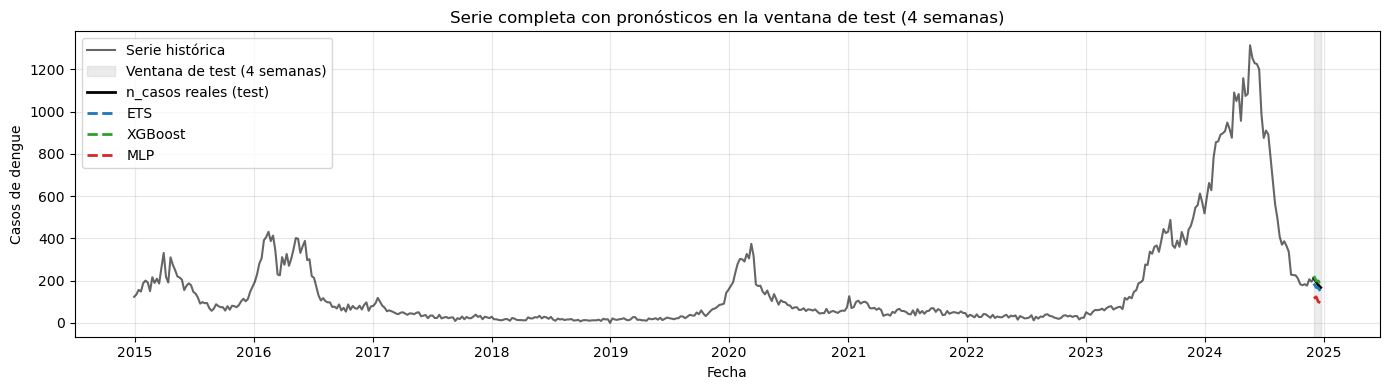

In [92]:
# Serie completa con zona de test y predicciones 

y_all_series = df_feat["n_casos"].astype(float).reset_index(drop=True)

plt.figure(figsize=(14, 4))

# Serie histórica completa
plt.plot(dates_all, y_all_series, color="black", alpha=0.6, label="Serie histórica")

# Zona de test final sombreada
plt.axvspan(dates_all.iloc[test_start_idx],
            dates_all.iloc[test_end_idx-1],
            color="gray", alpha=0.15, label="Ventana de test (4 semanas)")

# Casos reales en el test
plt.plot(fechas_test, df_comp["casos_reales"], color="black", linewidth=2, label="n_casos reales (test)")

# Predicciones de cada modelo
plt.plot(fechas_test, df_comp["ETS_pred"], linestyle="--", color="tab:blue", linewidth=2,
         label="ETS")

plt.plot(fechas_test, df_comp["XGB_pred"], linestyle="--", color="tab:green", linewidth=2,
         label="XGBoost")

plt.plot(fechas_test, df_comp["MLP_pred"], linestyle="--", color="tab:red", linewidth=2,
         label="MLP")

plt.title("Serie completa con pronósticos en la ventana de test (4 semanas)")
plt.xlabel("Fecha")
plt.ylabel("Casos de dengue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


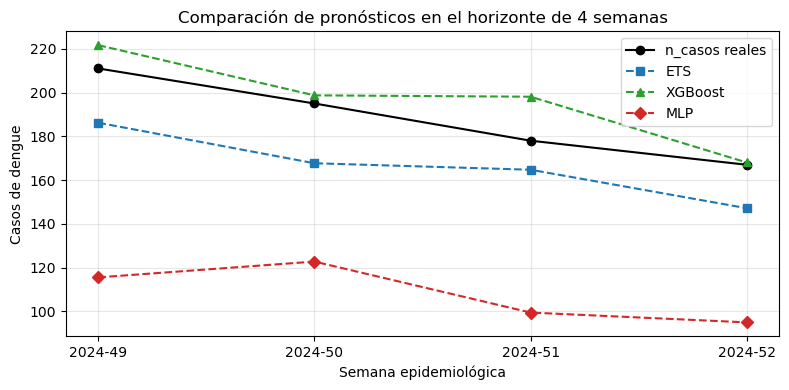

In [94]:
#solo test real + predicciones de los 3 modelos

plt.figure(figsize=(8, 4))


c_real  = "black"
c_ets   = "#1f77b4"  # azul
c_xgb   = "#2ca02c"  # verde
c_mlp   = "#d62728"  # rojo

plt.plot(df_comp["epi_week"], df_comp["casos_reales"],
         marker="o", linestyle="-", color=c_real, label="n_casos reales")

plt.plot(df_comp["epi_week"], df_comp["ETS_pred"],
         marker="s", linestyle="--", color=c_ets, label="ETS")

plt.plot(df_comp["epi_week"], df_comp["XGB_pred"],
         marker="^", linestyle="--", color=c_xgb, label="XGBoost")

plt.plot(df_comp["epi_week"], df_comp["MLP_pred"],
         marker="D", linestyle="--", color=c_mlp, label="MLP")

plt.title("Comparación de pronósticos en el horizonte de 4 semanas")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Casos de dengue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


**Conclusión:**

- XGBoost es el modelo con mejor rendimiento: logra el MAE, RMSE y MAPE más bajos y sigue muy de cerca la trayectoria real semana a semana. Es el candidato natural para el sistema de pronóstico operativo.
- ETS (Holt–Winters aditivo) funciona como un baseline estadístico sólido: reproduce bien la forma de la serie reciente, pero tiende a subestimar el nivel de casos en la ventana de test.
- MLP_PyTorch presenta errores considerablemente mayores y predicciones sistemáticamente subescaladas, lo que sugiere que, con el tamaño y la estructura de esta serie, las redes densas no ofrecen ventajas frente a los modelos basados en árboles o ETS.

La tabla con las metricas del rendimiento de los modelos  y la tabla reales vs predicciones respaldan esta conclusión y muestran de forma clara que XGBoost domina tanto en métricas globales como en cada una de las cuatro semanas de horizonte.

### 7) Optimizar XGBoost con Optuna

Dado que XGBoost fue el mejor modelo global en la fase comparativa, se realizó una optimización bayesiana de sus hiperparámetros utilizando Optuna. La búsqueda se plantea directamente sobre el esquema de validación rolling empleado en este trabajo (ventanas crecientes, horizonte de 4 semanas y salto de 4 semanas), de modo que la métrica objetivo a minimizar es el RMSE medio en validación temporal.

Este procedimiento permite ajustar automáticamente hiperparámetros clave del modelo (profundidad de los árboles, tasa de aprendizaje, número de estimadores, entre otros) sin introducir fuga de información, ya que en cada iteración solo se entrena con datos pasados y se evalúa en semanas futuras dentro del conjunto de train+validación.


In [95]:

def build_xgb(trial):
    """
    Espacio de búsqueda de hiperparámetros para XGBoost.
    Reutiliza el mismo esquema de validación rolling que en 5.4.
    """
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        # Parámetros fijos razonables
        "objective": "reg:squarederror",
        "random_state": 42,
        "tree_method": "hist",   # más rápido en CPU
        "n_jobs": -1,
    }
    return XGBRegressor(**params)


def objective(trial):
    """
    Función objetivo de Optuna:
    devuelve el RMSE medio en la validación rolling (horizonte H, paso STEP),
    sin fuga de información.
    """
    model = build_xgb(trial)

    rmses = []
    t = start_idx

    while t <= end_idx:
        # Train hasta t (solo pasado)
        X_train = X_all[:t]
        y_train = y_all[:t]

        # Validación: siguientes H semanas
        X_val = X_all[t:t+H]
        y_val = y_all[t:t+H]

        model.fit(X_train, y_train, verbose=False)
        y_hat = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_hat))
        rmses.append(rmse)

        t += STEP

    return float(np.mean(rmses))


In [96]:
# ajustar estos valores según tiempo disponible
N_TRIALS = 30     
TIMEOUT  = None   # o en segundos, ej. 600

study = optuna.create_study(direction="minimize")
study.optimize(
    objective,
    n_trials=N_TRIALS,
    timeout=TIMEOUT,
    show_progress_bar=True
)

print("Mejor RMSE_mean (rolling):", study.best_value)
print("\nMejores hiperparámetros XGBoost (Optuna):")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


[I 2026-04-30 14:01:19,530] A new study created in memory with name: no-name-40b1f37d-bac3-455f-a01b-63ead67bb4b1
Best trial: 0. Best value: 66.4208:   3%|▎         | 1/30 [00:50<24:26, 50.58s/it]

[I 2026-04-30 14:02:10,114] Trial 0 finished with value: 66.42075729412116 and parameters: {'n_estimators': 736, 'max_depth': 7, 'learning_rate': 0.03759389516332716, 'subsample': 0.7993871131355657, 'colsample_bytree': 0.726312196812568, 'min_child_weight': 1.42770027839162, 'gamma': 0.7328467823229351}. Best is trial 0 with value: 66.42075729412116.


Best trial: 0. Best value: 66.4208:   7%|▋         | 2/30 [01:08<14:41, 31.47s/it]

[I 2026-04-30 14:02:28,196] Trial 1 finished with value: 75.72314738670491 and parameters: {'n_estimators': 524, 'max_depth': 3, 'learning_rate': 0.07341580244507158, 'subsample': 0.6054911876131787, 'colsample_bytree': 0.8942168718461596, 'min_child_weight': 9.98474271575413, 'gamma': 0.9754525587856056}. Best is trial 0 with value: 66.42075729412116.


Best trial: 0. Best value: 66.4208:  10%|█         | 3/30 [01:38<13:47, 30.64s/it]

...

[I 2026-04-30 14:13:16,944] Trial 27 finished with value: 62.40309165192029 and parameters: {'n_estimators': 409, 'max_depth': 4, 'learning_rate': 0.07317220602139468, 'subsample': 0.8347745884657682, 'colsample_bytree': 0.8698200242015252, 'min_child_weight': 2.4402704079777533, 'gamma': 1.8330225180850643}. Best is trial 11 with value: 61.11169527344433.


Best trial: 11. Best value: 61.1117:  97%|█████████▋| 29/30 [12:20<00:22, 22.34s/it]

[I 2026-04-30 14:13:40,239] Trial 28 finished with value: 62.186137187174594 and parameters: {'n_estimators': 361, 'max_depth': 5, 'learning_rate': 0.02855096042284283, 'subsample': 0.9667774226278466, 'colsample_bytree': 0.8234333082523957, 'min_child_weight': 4.382313686002393, 'gamma': 3.2220185303095974}. Best is trial 11 with value: 61.11169527344433.


Best trial: 11. Best value: 61.1117: 100%|██████████| 30/30 [13:11<00:00, 26.38s/it]

[I 2026-04-30 14:14:30,964] Trial 29 finished with value: 64.53485925619222 and parameters: {'n_estimators': 573, 'max_depth': 7, 'learning_rate': 0.043917129073120086, 'subsample': 0.7869185715973657, 'colsample_bytree': 0.7650545692549936, 'min_child_weight': 1.5408278159193527, 'gamma': 4.751507626414768}. Best is trial 11 with value: 61.11169527344433.
Mejor RMSE_mean (rolling): 61.11169527344433

Mejores hiperparámetros XGBoost (Optuna):
  n_estimators: 621
  max_depth: 5
  learning_rate: 0.11955788277878864
  subsample: 0.9205708490303672
  colsample_bytree: 0.9142451982227799
  min_child_weight: 2.6240715168007642
  gamma: 2.01930423775002


### 7.1) Reentrenamiento con los mejores parámetros

In [97]:

# Reentrenamiento final de XGBoost optimizado (Test 4 sem)

# (usamos las mismas X_all, y_all de la sección de ML)

TEST_H = 4
N = len(y_all)

test_start = N - TEST_H
test_end   = N

X_train_ml = X_all[:test_start]
y_train_ml = y_all[:test_start]
X_test_ml  = X_all[test_start:test_end]
y_test_ml  = y_all[test_start:test_end]

print("XGBoost – train:", X_train_ml.shape, "test:", X_test_ml.shape)

# --- 2) Parámetros óptimos de Optuna -------------------------
best_xgb_params = study.best_params.copy()
best_xgb_params.update({
    "objective": "reg:squarederror",
    "random_state": 42,
    "tree_method": "hist",
})

best_xgb_params


XGBoost – train: (464, 79) test: (4, 79)


{'n_estimators': 621,
 'max_depth': 5,
 'learning_rate': 0.11955788277878864,
 'subsample': 0.9205708490303672,
 'colsample_bytree': 0.9142451982227799,
 'min_child_weight': 2.6240715168007642,
 'gamma': 2.01930423775002,
 'objective': 'reg:squarederror',
 'random_state': 42,
 'tree_method': 'hist'}

In [98]:
#  Entrenar modelo final y predecir en el test 

xgb_final_optuna = XGBRegressor(**best_xgb_params)
xgb_final_optuna.fit(X_train_ml, y_train_ml)

y_pred_xgb_opt = xgb_final_optuna.predict(X_test_ml)

# --- 4) Métricas en el test final ----------------------------

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = float(
        np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-6))) * 100
    )
    return mae, rmse, mape

mae_xgb_op, rmse_xgb_op, mape_xgb_op = compute_metrics(y_test_ml, y_pred_xgb_opt)
print(f"XGBoost óptimo – Test final | MAE={mae_xgb_op:.2f}, RMSE={rmse_xgb_op:.2f}, MAPE={mape_xgb_op:.2f}")


XGBoost óptimo – Test final | MAE=12.82, RMSE=15.11, MAPE=7.01


In [99]:

res_xgb = pd.DataFrame([
    
    {
        "Modelo": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "MAPE": mape_xgb
    },
    {
        "Modelo": "XGBoost_Optuna",
        "MAE": mae_xgb_op,
        "RMSE": rmse_xgb_op,
        "MAPE": mape_xgb_op
    }
])

res_xgb.sort_values("RMSE").reset_index(drop=True)

,Modelo,MAE,RMSE,MAPE
0,XGBoost,8.870876,11.530647,4.714287
1,XGBoost_Optuna,12.816639,15.105718,7.007101


**Conclusión:**

La optimización no supero el desempeño presentado por XGBoost original, sugiriendo que:
- El modelo se encontraba cerca de un óptimo local con los parametros iniciales.
- El dataset es pequeño, por ende los modelos de mayor complejitud tienen a sobre-ajustarse durante la busqueda.

Para efectos de diseño del sistema de alerta temprana:
- XGBoost original sigue siendo el modelo final recomendado, por ser más preciso, más estable y computacionalmente más eficiente.
- Predicciones futuras reales, más allá del dataset.
- Análisis de importancia de variables (feature importance).
- Sistema tipo “semaforo epidemiológico” basado en percentiles.

### 8) Feature Importance - XGBoost final

En esta sección analizamos la importancia relativa de cada variable usada por el modelo XGBoost final. El objetivo es identificar qué características aportan más información al pronóstico semanal de dengue, esto permite:
- Interpretar comportamiento del modelo.
- Comprender qué factores ambientales o epidemiológicos son más determinantes.
- Seleccionar variables clave para un futuro sistema de alerta temprana.

XGBoost permite medir la importancia de las variables mediante diferentes métricas, entre ellas gain, weight y cover. En este proyecto utilizaremos gain, que representa la mejora promedio en la pérdida (error) cuando un split utiliza una determinada característica.

In [100]:


importance_gain = xgb_final.get_booster().get_score(importance_type="gain")

df_imp = (
    pd.DataFrame({
        "feature": list(importance_gain.keys()),
        "gain": list(importance_gain.values())
    })
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

# Mapeo f0 → verdadero nombre
def map_feature(f):
    idx = int(f.replace("f", ""))
    return feature_cols_ml[idx]

df_imp["feature_real"] = df_imp["feature"].apply(map_feature)

archivo = "xgb_feature_importance.csv"
df_imp.to_csv(archivo, index=False, decimal=",", sep=";")
print(f"Feature importance guardada en '{archivo}'")

df_imp.head(40)


Feature importance guardada en 'xgb_feature_importance.csv'


,feature,gain,feature_real
0,f5,584215.625000,n_casos_lag1
1,f35,161532.250000,precip_fore_cum4
2,f13,62356.093750,n_casos_mm4
3,f69,60009.019531,tmin_fore_mm6
4,f6,50903.984375,n_casos_lag2
5,f37,29207.878906,precip_fore_cum8
6,f18,17695.011719,n_casos_cum4
7,f32,13275.178711,precip_fore_mm4
8,f7,12209.846680,n_casos_lag3
9,f33,11244.232422,precip_fore_mm6


In [91]:
df_imp.tail(36)

,feature,gain,feature_real
40,f25,202.598160,precip_fore_lag3
41,f76,192.243500,ndvi_mm4
42,f47,154.884521,ndwi_mm4
43,f40,148.690277,ndwi_lag2
44,f55,140.946594,tmax_fore_lag3
45,f59,136.315826,tmax_fore_mm4
46,f3,129.258072,ndwi
47,f0,129.132416,ndvi
48,f38,124.957718,precip_fore_diff1
49,f78,123.116623,ndvi_mm8


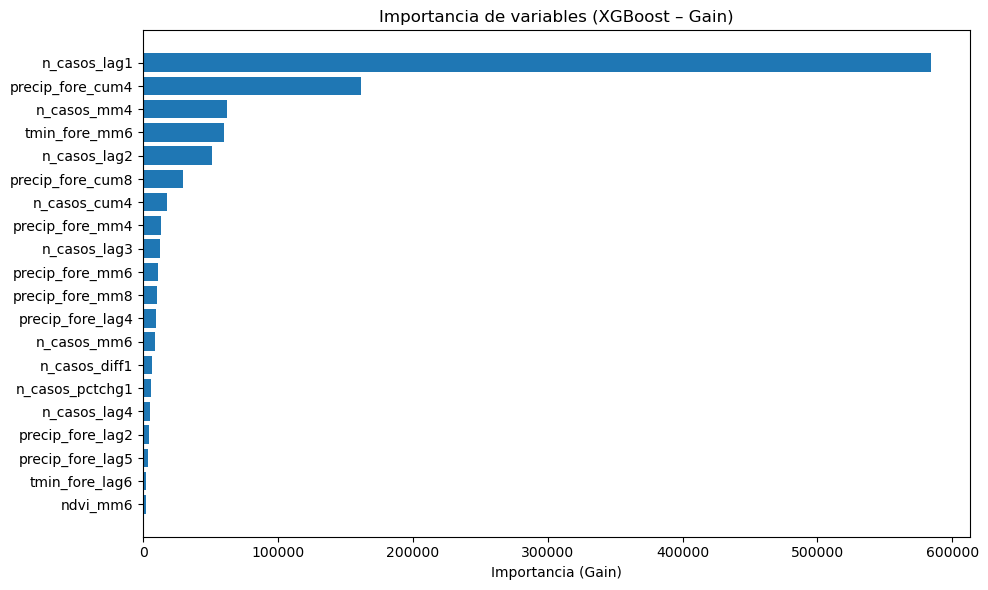

In [101]:
plt.figure(figsize=(10,6))
plt.barh(df_imp["feature_real"].head(20), df_imp["gain"].head(20), color="tab:blue")
plt.gca().invert_yaxis()
plt.title("Importancia de variables (XGBoost – Gain)")
plt.xlabel("Importancia (Gain)")
plt.tight_layout()
plt.show()


**Conclusiones:**

Las feature importance revelan que el modelo se apoya principalmente de dinámicas autoregresivas recientes de la serie de dengue y en componentes climáticos agregados, lo cual es consistente con la literatura epidemiológica:
- n_casos_lag1 es, por amplio margen, la variable más determinante. Esto confirma que la persistencia temporal de la transmisión es el principal motor del pronóstico a corto plazo.
- precip_fore_cum4 aparece como el segundo predictor más influyente, indicando que la acumulación de lluvias en ventanas de varias semanas aporta información crítica para anticipar aumentos en los casos.
- Variables como n_casos_mm4, tmin_fore_mm6, n_casos_lag2, y diferentes acumulados/rezagos de precipitación continúan entre los primeros lugares, mostrando que el modelo captura tanto tendencias internas de la serie como efectos ambientales retardados.
- Los índices de vegetación (NDVI/NDWI) y diferencias semanales de temperatura o precipitación aparecen con menor peso, pero continúan aportando valor complementario al explicar variaciones más finas.

Este orden de importancia valida empíricamente la estructura del fenómeno y sustenta que estas variables deben mantenerse dentro del conjunto final para la construcción de alertas tempranas.


### 9) Sistema de Alerta Temprana basado en Percentiles (Semáforo Epidemiológico)

En esta sección se construye un sistema de alerta temprana a partir de las predicciones semanales del mejor modelo obtenido (XGBoost), utilizando un enfoque tipo canal endémico basado en percentiles históricos. La idea es traducir los pronósticos de casos de dengue en niveles de riesgo operativos (bajo, moderado, alto, muy alto), que puedan usarse como insumo para la vigilancia epidemiológica.

Para ello, se calcula, para cada semana epidemiológica, la distribución histórica de casos y sus percentiles 25, 50 y 75. Estos umbrales definen un semáforo simple:

- n_casos < P25  --> Bajo
- P25 < n_casos < P50 --> Moderado
- P50 < n_casos < P75 --> Alto
- P75 < n_casos  --> Muy alto o Epidémico

Primero se aplicará este semáforo sobre las 4 semanas de test final (no utilizadas en el entrenamiento), comparando los niveles de riesgo derivados de las predicciones con los casos observados. Esto permite evaluar si el sistema habría emitido señales de alerta coherentes con la realidad reciente.


#### 9.1) Cálculo de percentiles históricos por semana epidemiológica

In [102]:
from datetime import timedelta

# Última fecha disponible en la serie
max_date = df_util["epi_date"].max()

# Rango de 5 años hacia atrás
start_5y = max_date - pd.DateOffset(years=5)

# Filtrar
df_canal_5y = df_util[df_util["epi_date"] >= start_5y].copy()

print("Rango usado para canal endémico:")
print(df_canal_5y["epi_date"].min(), "→", df_canal_5y["epi_date"].max())
print("Total filas:", len(df_canal_5y))


Rango usado para canal endémico:
2019-12-23 00:00:00 → 2024-12-23 00:00:00
Total filas: 262


In [103]:

from datetime import timedelta


max_date = df_util["epi_date"].max()
# Rango de 5 años hacia atrás
start_5y = max_date - pd.DateOffset(years=5)

# ultimos 5 años
df_canal = df_util[df_util["epi_date"] >= start_5y].copy()


# Extraemos la semana del año
df_canal["week"] = df_canal["epi_date"].dt.isocalendar().week.astype(int)

# Agrupamos por semana y calculamos percentiles históricos
canal_endemico = (
    df_canal.groupby("week")["n_casos"]
    .agg(
        P25=lambda x: np.percentile(x, 25),
        P50=lambda x: np.percentile(x, 50),
        P75=lambda x: np.percentile(x, 75)
    )
    .reset_index()
)

canal_endemico.head(52)


,week,P25,P50,P75
0,1,50.00,126.0,157.00
1,2,43.00,70.0,175.00
2,3,38.00,75.0,192.00
3,4,53.00,99.0,238.00
4,5,61.00,105.0,279.00
5,6,60.00,91.0,302.00
6,7,62.00,98.0,301.00
7,8,67.00,100.0,290.00
8,9,59.00,92.0,326.00
9,10,70.00,70.0,305.00


In [104]:
def clasificar_riesgo(valor, p25, p50, p75):
    if valor < p25:
        return "Bajo"
    elif valor < p50:
        return "Moderado"
    elif valor < p75:
        return "Alto"
    else:
        return "Muy Alto"


In [105]:
preds_xgb = df_comp.drop(columns=["ETS_pred", "MLP_pred"])
preds_xgb

,fecha,epi_week,casos_reales,XGB_pred
0,2024-12-02,2024-49,211.0,221.634949
1,2024-12-09,2024-50,195.0,198.707870
2,2024-12-16,2024-51,178.0,198.096848
3,2024-12-23,2024-52,167.0,168.043839


In [108]:
# Creamos tabla base del test final
df_test_semaforo = preds_xgb  # contiene fecha, reales y predicciones

# Extraemos semana epidemiológica
df_test_semaforo["week"] = df_test_semaforo["fecha"].dt.isocalendar().week.astype(int)

# Mezclamos con percentiles históricos
df_test_semaforo = df_test_semaforo.merge(canal_endemico, on="week", how="left")

# Clasificación para reales y predicciones
df_test_semaforo["riesgo_real"] = df_test_semaforo.apply(
    lambda row: clasificar_riesgo(row["casos_reales"], row["P25"], row["P50"], row["P75"]),
    axis=1
)

df_test_semaforo["riesgo_pred_xgb"] = df_test_semaforo.apply(
    lambda row: clasificar_riesgo(row["XGB_pred"], row["P25"], row["P50"], row["P75"]),
    axis=1
)
df_test_semaforo = df_test_semaforo.drop(columns=["week"])
df_test_semaforo


,fecha,epi_week,casos_reales,XGB_pred,P25,P50,P75,riesgo_real,riesgo_pred_xgb
0,2024-12-02,2024-49,211.0,221.634949,45.00,47.0,211.00,Muy Alto,Muy Alto
1,2024-12-09,2024-50,195.0,198.707870,54.00,55.0,195.00,Muy Alto,Muy Alto
2,2024-12-16,2024-51,178.0,198.096848,47.00,58.0,178.00,Muy Alto,Muy Alto
3,2024-12-23,2024-52,167.0,168.043839,48.75,99.5,160.75,Muy Alto,Muy Alto
